# U.S. gasoline supply, demand, and stocks

This project uses EIA monthly data to understand how gasoline supply and demand translate into inventory builds and draws. It combines a historical barrel balance with a comparison of stock-forecasting methods. The aim is to explain the market relationships and test whether the forecasts improve on simple benchmarks.

The target is total gasoline stocks: finished motor gasoline plus motor gasoline blending components. Keeping both categories together prevents the conversion of blendstocks into finished gasoline from appearing to create new total gasoline supply.

We model the five Petroleum Administration for Defense Districts (PADDs) separately and sum them to obtain U.S. stocks. These are the East Coast, Midwest, Gulf Coast, Rocky Mountains, and West Coast. Regional forecasts matter because a comfortable national inventory total can coexist with a tighter regional balance.

The outlook uses historical patterns. It does not explicitly model refinery turnaround schedules, weather, fuel-specification changes, or price responses. It provides a baseline for an S&D view, not a complete physical or trading forecast.

### COVID exclusion

March 2020 through March 2021 is excluded from model fitting because that disruption may not represent the market relationships this study aims to capture. This is a modeling assumption; removing an unusual period does not prove the remaining relationships will hold in future disruptions.

Training rows are also excluded when their one-month, two-month, or twelve-month inputs fall in that interval. With these inputs, excluded stock-training targets extend through March 2022. Seasonal stock changes require both stock observations to fall outside the exclusion. Flow fits also omit excluded observations.

The calendar stays intact, so one year earlier still means twelve calendar months. Development scoring excludes COVID target months, and the year-ahead development paths avoid the interval. The final test covers July 2024–June 2026. It is excluded from the current selection process, but has been reviewed during project development and is therefore a retrospective check.

### Reading guide

Start with the balance checks, then compare forecast errors with the unchanged-stocks benchmark. The regional review shows where the model adds value and where it falls short. Code and saved outputs are included for rerunning the analysis.

In [1]:
# Run cells from top to bottom: later cells reuse the data, functions, and fitted
# models created here. pandas/NumPy handle monthly tables and arrays, sklearn
# and XGBoost fit models, matplotlib draws charts, and joblib saves estimators.
from pathlib import Path
from datetime import datetime, timezone
from concurrent.futures import ThreadPoolExecutor
import hashlib, io, json, platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests, joblib, sklearn, xgboost
from sklearn.exceptions import ConvergenceWarning
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.linear_model import LinearRegression, Ridge, HuberRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, SplineTransformer
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor
from IPython.display import display, Markdown

# Only input data are external. No local Python module is imported.
# Support execution from either the product folder or the commodities workspace.
# Fail early if the saved EIA observation CSV cannot be found.
HERE=Path.cwd()
if not (HERE/'data/eia_observations.csv').exists():
    HERE=HERE/'oil'/'us_snd_gasoline'
assert (HERE/'data/eia_observations.csv').exists(), 'Keep the data folder beside this notebook.'
OUTPUT=HERE/'model_output'
# These settings affect chart/table presentation only, not stored model values.
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns',20)
pd.set_option('display.float_format',lambda x:f'{x:,.2f}')

# Dates represent observation months using their first day. Both exclusion
# endpoints are inclusive; keep the raw calendar intact so lags retain their meaning.
COVID_START = pd.Timestamp('2020-03-01')
COVID_END = pd.Timestamp('2021-03-01')


# Return one Boolean per date: True means outside the excluded COVID interval.
def outside_covid(months):
    dates = pd.DatetimeIndex(months)
    return ~((dates >= COVID_START) & (dates <= COVID_END))


# Filter fitting rows after constructing lagged features on the intact calendar.
# A clean target is insufficient if one of its direct lag inputs is excluded.
def training_rows(frame):
    """Exclude COVID targets and any training row whose direct inputs touch COVID."""
    dates = pd.DatetimeIndex(frame.month)
    keep = outside_covid(dates)
    # lag1 stocks/flows, lag2 for the latest change, lag12 for annual stocks.
    for lag in [1, 2, 12]:
        keep &= outside_covid(dates - pd.DateOffset(months=lag))
    return frame.loc[keep]


# Create chronological expanding-window folds; never shuffle time-series rows.
# This filter concerns target dates; fitting applies the stricter lag-input filter.
def validation_splits(frame, folds=10, test_size=None):
    """Split eligible target dates, retaining real calendar positions and lag dates."""
    allowed = np.flatnonzero(outside_covid(frame.month))
    splitter = TimeSeriesSplit(n_splits=folds, test_size=test_size)
    # Map positions within eligible dates back to the original frame. A test block
    # of 12 eligible observations may span more than 12 calendar months.
    return [(allowed[tr], allowed[te]) for tr, te in splitter.split(allowed)]


# Search backward in annual steps for six eligible year-long development paths.
# Each origin leaves its next 12 forecast months inside development history.
def recursive_origins(development_end, count=6):
    """Use six full test years that do not overlap the excluded interval."""
    origins = []
    cutoff = development_end - pd.DateOffset(years=1)
    while len(origins) < count:
        months = pd.date_range(cutoff + pd.offsets.MonthBegin(), periods=12, freq='MS')
        if outside_covid(months).all() and outside_covid([cutoff]).all():
            origins.append(cutoff)
        cutoff -= pd.DateOffset(years=1)
    return sorted(origins)

## 1. Sources, units, and product boundary

EIA publishes month-end stocks and calendar-month supply/disposition volumes. Stock levels and monthly balance volumes are measured in **thousand barrels (kb)**; charts use **million barrels (kb / 1,000)**. Product supplied is a domestic demand proxy derived from the petroleum balance, not an independent measure of retail sales. For the total gasoline boundary, net refinery/blender production equals finished gasoline net production **minus blending-component refinery/blender net inputs**. This offsets internal conversion into finished gasoline instead of counting it as new total gasoline supply.

Source references: [EIA balance definitions](https://www.eia.gov/dnav/pet/TblDefs/pet_sum_snd_tbldef2.asp), [PADD 1 balance table](https://www.eia.gov/dnav/pet/pet_sum_snd_d_r10_mbbl_m_cur.htm), and [total motor gasoline definition](https://www.eia.gov/dnav/pet/TblDefs/pet_sum_sndw_tbldef2.asp).

The source manifest contains 95 product/region records: 93 EIA spreadsheets and two balance-page snapshots documenting no published blending-component biofuel-production series in PADDs 3 and 4. Those two inputs use flagged structural zeros. The original EIA spreadsheets and download dates are saved under `data/`. The model uses history from January 2007. This matches the crude archive's starting period and avoids fitting across still earlier reporting regimes.

No-data-reported or absent cells in sparse imports, exports, net receipts, and biofuel series are **assumed zero and flagged**. Withheld/unavailable text markers are not replaced. Core missing observations cause an error. The balance reconciliation below checks whether those assumptions are consistent with reported totals. A common complete endpoint is required across all five PADDs.

### Series map and input preparation

This is the exact EIA code map and sign convention. `load_panel` reshapes source observations into a complete monthly PADD panel, retains zero assumptions, retains finished and total gasoline stock scope, and calculates historical balance residuals.

In [2]:
# PADDs are the five Petroleum Administration for Defense Districts. Series
# templates substitute {p} with the district number when identifying source data.
PADD_NAMES = {1: 'East Coast', 2: 'Midwest', 3: 'Gulf Coast', 4: 'Rocky Mountain', 5: 'West Coast'}
# Total motor gasoline = finished motor gasoline + motor gasoline blending components.
# Preserve each constituent series; derive total net production by subtracting
# blending-component refinery/blender NET inputs from finished net production.
FINISHED_CODES = {'production_kb': 'MGFRPP{p}1', 'demand_kb': 'MGFUPP{p}1',
    'imports_kb': 'MGFIMP{p}1', 'exports_kb': 'MGFEXP{p}1',
    'net_receipts_kb': 'MGFNRP{p}1', 'adjustments_kb': 'MGFUA_R{p}0_1',
    'biofuels_kb': 'M_EPM0F_YNP_R{p}0_MBBL',
    'stock_kb': 'MGFSTP{p}1', 'reported_stock_change_kb': 'MGFSCP{p}1'}
BLENDING_CODES = {'net_inputs_kb': 'MBCRIP{p}1', 'demand_kb': 'MBCUPP{p}1',
    'imports_kb': 'MBCIMP{p}1', 'exports_kb': 'MBCEXP{p}1',
    'net_receipts_kb': 'MBCNRP{p}1', 'adjustments_kb': 'MBCUA_R{p}0_1',
    'biofuels_kb': 'M_EPOBG_YNP_R{p}0_MBBL',
    'stock_kb': 'MBCSTP{p}1', 'reported_stock_change_kb': 'MBCSCP{p}1'}
CODES = {**{'finished_' + c: v for c,v in FINISHED_CODES.items()},
         **{'blending_' + c: v for c,v in BLENDING_CODES.items()},
         'stock_kb': 'MGTSTP{p}1'}
# Keep this order aligned with SIGNS: the dot product uses +1 for supply
# additions and -1 for disposition to reconstruct net supply.
FLOWS = ['production_kb', 'demand_kb', 'imports_kb', 'exports_kb',
         'net_receipts_kb', 'adjustments_kb', 'biofuels_kb']
SIGNS = [1, -1, 1, -1, 1, 1, 1]
SPARSE = {prefix + c for prefix in ['finished_', 'blending_']
          for c in ['imports_kb', 'exports_kb', 'biofuels_kb', 'net_receipts_kb']}

In [3]:
# Return one row per PADD/month with flows, month-end stocks, assumption flags,
# and balance diagnostics, starting from the saved long-form EIA observations.
def load_panel(data_dir=HERE / 'data', start='2007-01-01'):
    # Parse timestamps for exact calendar reindexing and month-length calculations.
    raw = pd.read_csv(Path(data_dir) / 'eia_observations.csv', parse_dates=['month'])
    # The pivot requires a single observation per month/PADD/component combination.
    if raw.duplicated(['month', 'padd', 'component']).any():
        raise ValueError('Duplicate EIA observations')
    panels = []
    for p in PADD_NAMES:
        r = raw[raw.padd.eq(p)]
        # Use the latest observed stock month as this district's provisional endpoint.
        end = r[r.component.eq('stock_kb') & r.value.notna()].month.max()
        index = pd.date_range(start, end, freq='MS')
        # Turn component names into columns, then expose absent months on a continuous
        # month-start calendar. Reindexing does not interpolate missing observations.
        wide = r.pivot(index='month', columns='component', values='value').reindex(index)
        for c in sorted(SPARSE):
            rows = r[r.component.eq(c)].set_index('month')
            # Missing calendar rows in sparse trade/biofuel sheets are an explicit
            # no-reported-flow assumption, not interpolation from future values.
            absent = ~wide.index.isin(rows.index)
            # Combine source zero flags with wholly absent sparse-series rows. An explicit
            # unavailable value on an existing row remains missing instead of becoming zero.
            wide[c + '_assumed_zero'] = rows.assumed_zero.reindex(index).astype("boolean").fillna(False).astype(bool) | absent
            wide.loc[absent, c] = 0.0
        wide['padd'] = p
        wide['padd_name'] = PADD_NAMES[p]
        wide.index.name = 'month'
        panels.append(wide.reset_index())
    panel = pd.concat(panels, ignore_index=True)
    core = list(CODES)
    # Find the last month complete in all five districts, then trim to a shared
    # endpoint so national totals compare the same observation months.
    valid = panel[core].notna().all(axis=1)
    common = panel[valid].groupby('month').padd.nunique()
    end = common[common.eq(5)].index.max()
    panel = panel[panel.month.le(end)].copy()
    # Earlier unresolved gaps still fail validation: trimming the endpoint does not
    # authorize filling withheld values or dropping an incomplete district.
    if panel[core].isna().any().any():
        raise ValueError('Unresolved missing core data; inspect the source snapshots')
    if not panel.groupby('padd').size().eq(len(pd.date_range(start, end, freq='MS'))).all():
        raise ValueError('Incomplete PADD calendar')
    # Boundary reconciliation: internal blending inputs offset finished output.
    # Subtract blending-component net inputs from finished gasoline net output to
    # avoid counting an internal transfer as production of total gasoline.
    panel['production_kb'] = panel.finished_production_kb - panel.blending_net_inputs_kb
    for c in FLOWS[1:] + ['reported_stock_change_kb']:
        panel[c] = panel['finished_' + c] + panel['blending_' + c]
    # Compare published total stocks with finished plus blending stocks; tolerate
    # 1 kb of rounding while retaining the independently published total as target.
    panel['stock_component_residual_kb'] = panel.stock_kb - panel.finished_stock_kb - panel.blending_stock_kb
    if panel.stock_component_residual_kb.abs().max() > 1:
        raise ValueError('Published total gasoline stocks do not match the two constituent stocks')
    panel['total_gasoline_stock_kb'] = panel.stock_kb  # explicit compatibility alias
    # Shift within each district so prior stock never comes from another PADD.
    # The first month has no predecessor and therefore a missing stock change.
    panel['previous_stock_kb'] = panel.groupby('padd').stock_kb.shift(1)
    # Gasoline flows are monthly thousand barrels, so their signed sum can be
    # compared directly with the month-to-month stock change.
    panel['balance_kb'] = panel[FLOWS].to_numpy() @ SIGNS
    panel['stock_change_kb'] = panel.stock_kb - panel.previous_stock_kb
    panel['accounting_residual_kb'] = panel.stock_change_kb - panel.balance_kb
    # Separate stock-level versus reported-change discrepancies from reported-change
    # versus flow discrepancies; together they explain the accounting residual.
    panel['reported_change_residual_kb'] = panel.stock_change_kb - panel.reported_stock_change_kb
    panel['flow_reporting_residual_kb'] = panel.reported_stock_change_kb - panel.balance_kb
    return panel

### Optional data collection, included for completeness

The code below downloads EIA history and saves the original spreadsheets. Run All uses the saved data. Set `REFRESH_SOURCES=True` to download a new release; revisions may change the results.

In [4]:
# Optional refresh downloads and archives source bytes, creates normalized
# observations and provenance, then validates the result through load_panel.
def refresh_data(data_dir=HERE / 'data'):
    data_dir = Path(data_dir)
    raw_dir = data_dir / 'raw'
    raw_dir.mkdir(parents=True, exist_ok=True)
    def download(task):
        p, component, code = task
        if component == 'blending_biofuels_kb' and p in [3, 4]:
            # EIA's balance page has no biofuel-production series for this
            # product/region. Archive that page and flag the zero convention.
            url = f'https://www.eia.gov/dnav/pet/pet_sum_snd_d_r{p}0_mbbl_m_cur.htm'
            response = requests.get(url, timeout=60)
            # Reject HTTP errors before interpreting the response as valid EIA source data.
            response.raise_for_status()
            if 'Motor Gasoline Blend. Comp.' not in response.text or code in response.text:
                raise ValueError(f'Review structural-zero model for {code}')
            filename = f'blending_biofuels_padd{p}_source.html'
            (raw_dir / filename).write_bytes(response.content)
            months = pd.date_range('1981-01-01', pd.Timestamp.now(), freq='MS')
            frame = pd.DataFrame({'month': months, 'padd': p, 'component': component,
                'value': 0.0, 'assumed_zero': True, 'series_id': code})
            return frame, {'padd': p, 'component': component, 'series_id': code,
                'url': url, 'title': 'No published blending-component biofuel production series; assumed zero',
                'source_file': filename, 'kind': 'structural_zero',
                'sha256': hashlib.sha256(response.content).hexdigest(),
                'retrieved_utc': datetime.now(timezone.utc).isoformat(), 'rows': len(frame)}
        url = f'https://www.eia.gov/dnav/pet/hist_xls/{code}m.xls'
        response = requests.get(url, timeout=60)
        # Reject HTTP errors before interpreting the response as valid EIA source data.
        response.raise_for_status()
        content = response.content
        # Read the worksheet below its header rows, retaining text markers so unavailable
        # and withheld observations remain distinguishable from genuinely blank cells.
        table = pd.read_excel(io.BytesIO(content), sheet_name='Data 1', header=2, keep_default_na=False)
        if table.shape[1] != 2 or 'Thousand Barrels' not in str(table.columns[1]):
            raise ValueError(f'Unexpected units/schema: {code}')
        (raw_dir / f'{code}m.xls').write_bytes(content)
        original = table.iloc[:, 1]
        values = pd.to_numeric(original, errors='coerce')
        # Excel empty cells correspond to no-data-reported on these sparse series.
        # Preserve text markers so W/NA cannot silently turn into zero.
        empty = original.isna() | original.astype(str).str.strip().isin(['', '-'])
        zero = values.isna() & empty & (component in SPARSE)
        values = values.mask(zero, 0.0)
        frame = pd.DataFrame({'month': pd.to_datetime(table.iloc[:, 0]).dt.to_period('M').dt.to_timestamp(),
            'padd': p, 'component': component, 'value': values, 'assumed_zero': zero, 'series_id': code})
        # Sparse worksheets sometimes stop before the common archive endpoint;
        # calendar extension is handled explicitly by load_panel, with flags.
        # Record URL, retrieval time, and SHA-256 digest to identify the exact source
        # bytes underlying the observation snapshot.
        meta = {'padd': p, 'component': component, 'series_id': code, 'url': url,
                'source_file': f'{code}m.xls', 'kind': 'observed_series',
                'title': str(table.columns[1]), 'sha256': hashlib.sha256(content).hexdigest(),
                'retrieved_utc': datetime.now(timezone.utc).isoformat(), 'rows': len(frame)}
        return frame, meta
    # Create one task per district/component. Threads overlap download waits;
    # results are then combined into the observation CSV and provenance manifest.
    tasks = [(p, c, template.format(p=p)) for p in PADD_NAMES for c, template in CODES.items()]
    with ThreadPoolExecutor(max_workers=6) as pool:
        results = list(pool.map(download, tasks))
    raw = pd.concat([r[0] for r in results], ignore_index=True)
    raw.to_csv(data_dir / 'eia_observations.csv', index=False)
    (data_dir / 'source_manifest.json').write_text(json.dumps([r[1] for r in results], indent=2))
    return load_panel(data_dir)

In [5]:
# Choose whether to refresh source data. The default retains the saved data
# vintage, making the existing historical results reproducible.

# False reproduces the saved snapshot. True downloads current EIA sources and
# overwrites the local raw files, observation CSV, and source manifest.
REFRESH_SOURCES = False
if REFRESH_SOURCES:
    refresh_data(HERE/'data')

In [6]:
# Inspect source identifiers, observation coverage, and assumed-zero counts
# before fitting. Preserve constituent finished/blending series for audit.

manifest = pd.read_json(HERE / 'data/source_manifest.json')
display(manifest[manifest.padd.eq(1)][['component','series_id','title','url']])
panel = load_panel(HERE / 'data')
display(panel.groupby('padd').agg(start=('month','min'), end=('month','max'), months=('month','size')))
flags = [c for c in panel if c.endswith('_assumed_zero')]
display(panel.groupby('padd')[flags].sum().rename_axis('PADD: count of assumed-zero months'))

,component,series_id,title,url
0,finished_production_kb,MGFRPP11,East Coast (PADD 1) Refinery and Blender Net P...,https://www.eia.gov/dnav/pet/hist_xls/MGFRPP11...
1,finished_demand_kb,MGFUPP11,East Coast (PADD 1) Product Supplied of Finish...,https://www.eia.gov/dnav/pet/hist_xls/MGFUPP11...
2,finished_imports_kb,MGFIMP11,East Coast (PADD 1) Imports of Finished Motor ...,https://www.eia.gov/dnav/pet/hist_xls/MGFIMP11...
3,finished_exports_kb,MGFEXP11,East Coast (PADD 1) Exports of Finished Motor ...,https://www.eia.gov/dnav/pet/hist_xls/MGFEXP11...
4,finished_net_receipts_kb,MGFNRP11,"East Coast (PADD 1) Net Receipts by Pipeline, ...",https://www.eia.gov/dnav/pet/hist_xls/MGFNRP11...
5,finished_adjustments_kb,MGFUA_R10_1,East Coast (PADD 1) Supply Adjustment of Finis...,https://www.eia.gov/dnav/pet/hist_xls/MGFUA_R1...
6,finished_biofuels_kb,M_EPM0F_YNP_R10_MBBL,East Coast (PADD 1) Biofuels Plant Net Product...,https://www.eia.gov/dnav/pet/hist_xls/M_EPM0F_...
7,finished_stock_kb,MGFSTP11,East Coast (PADD 1) Ending Stocks of Finished ...,https://www.eia.gov/dnav/pet/hist_xls/MGFSTP11...
8,finished_reported_stock_change_kb,MGFSCP11,East Coast (PADD 1) Finished Motor Gasoline St...,https://www.eia.gov/dnav/pet/hist_xls/MGFSCP11...
9,blending_net_inputs_kb,MBCRIP11,East Coast (PADD 1) Refinery and Blender Net I...,https://www.eia.gov/dnav/pet/hist_xls/MBCRIP11...


,start,end,months
padd,,,
1,2007-01-01,2026-06-01,234
2,2007-01-01,2026-06-01,234
3,2007-01-01,2026-06-01,234
4,2007-01-01,2026-06-01,234
5,2007-01-01,2026-06-01,234


component,blending_biofuels_kb_assumed_zero,blending_exports_kb_assumed_zero,blending_imports_kb_assumed_zero,blending_net_receipts_kb_assumed_zero,finished_biofuels_kb_assumed_zero,finished_exports_kb_assumed_zero,finished_imports_kb_assumed_zero,finished_net_receipts_kb_assumed_zero
PADD: count of assumed-zero months,,,,,,,,
1,116,0,0,0,230,0,0,0
2,38,4,28,0,24,3,151,0
3,234,0,2,0,180,0,109,0
4,234,142,90,10,230,65,219,0
5,190,0,2,2,174,0,2,0


## 2. Reconstruct the historical balance first

For each PADD and month:

\[
S_t = S_{t-1} + P_t + I_t + N_t + A_t + B_t - D_t - X_t + \epsilon_t
\]

| Symbol | Meaning |
|---|---|
| S | Ending total gasoline stocks (finished + blending components) |
| P | Finished refinery/blender net production minus blending-component refinery/blender net inputs |
| I / X | Imports / exports |
| N | Net receipts from other PADDs; may be negative |
| A | EIA supply adjustments; may be negative |
| B | Biofuel plant net production summed across finished gasoline and blending components |
| D | Product supplied summed across both product categories |
| ε | Remaining accounting/reporting difference |

Flows in month **t** reconcile the inventory build or draw from the previous month-end to the current month-end.

A near-exact reconstruction is an accounting check, **not forecast accuracy**: product supplied already incorporates stock change in EIA's calculation. Consequently, actual target-month flows are never used to forecast that month's stocks.

,Max stock-level change less net supply (kb),Max stock-level change less reported change (kb),Max reported change less net supply (kb)
padd,,,
1,66.00,66.00,1.00
2,4.00,5.00,2.00
3,43.00,43.00,1.00
4,1.00,0.00,1.00
5,81.00,81.00,2.00


component,month,padd,previous_stock_kb,stock_kb,stock_change_kb,reported_stock_change_kb,balance_kb,accounting_residual_kb,flow_reporting_residual_kb,difference_pct_of_stocks,difference_kbd
228,2026-01-01,1,"58,895.00","68,046.00","9,151.00","9,085.00","9,085.00",66.00,0.00,0.10,2.13
696,2026-01-01,3,"93,187.00","94,303.00","1,116.00","1,159.00","1,159.00",-43.00,0.00,-0.05,-1.39
1164,2026-01-01,5,"30,639.00","31,085.00",446.00,527.00,527.00,-81.00,0.00,-0.26,-2.61


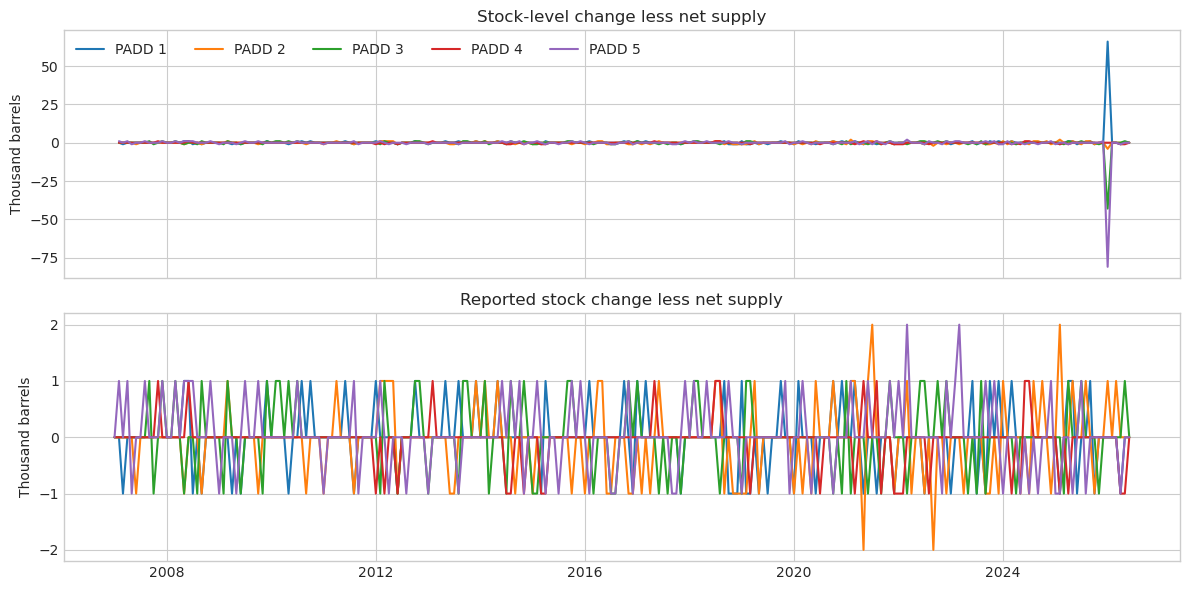

In [7]:
# Audit stock-level change against published stock change and net supply.
# Their residual decomposition is checked algebraically, allowing first-month
# NaNs. The >5 kb threshold selects displayed exceptions, not training exclusions.

checks = panel.groupby('padd').agg(
    maximum_balance_residual_kb=('accounting_residual_kb', lambda s: s.abs().max()),
    maximum_reported_change_difference_kb=('reported_change_residual_kb', lambda s: s.abs().max()),
    maximum_flow_reporting_residual_kb=('flow_reporting_residual_kb', lambda s: s.abs().max()))
display(checks.rename(columns={
    'maximum_balance_residual_kb':'Max stock-level change less net supply (kb)',
    'maximum_reported_change_difference_kb':'Max stock-level change less reported change (kb)',
    'maximum_flow_reporting_residual_kb':'Max reported change less net supply (kb)'}))
# Verify the two diagnostic residuals add to the total mismatch; initial
# NaNs are expected because the first stock observation has no predecessor.
np.testing.assert_allclose(panel.accounting_residual_kb,
    panel.reported_change_residual_kb + panel.flow_reporting_residual_kb, equal_nan=True)
exceptions = panel[panel.accounting_residual_kb.abs()>5].copy()
# Express each exception relative to inventory size and as a daily equivalent
# so its practical scale can be assessed alongside the monthly kb difference.
exceptions['difference_pct_of_stocks'] = 100*exceptions.accounting_residual_kb/exceptions.stock_kb
exceptions['difference_kbd'] = exceptions.accounting_residual_kb/exceptions.month.dt.days_in_month
display(exceptions[['month','padd','previous_stock_kb','stock_kb','stock_change_kb',
    'reported_stock_change_kb','balance_kb','accounting_residual_kb',
    'flow_reporting_residual_kb','difference_pct_of_stocks','difference_kbd']])
exceptions.to_csv(OUTPUT/'historical_balance_exceptions.csv', index=False)
fig, axes = plt.subplots(2,1,figsize=(12,6),sharex=True)
for p,g in panel.groupby('padd'):
    axes[0].plot(g.month,g.accounting_residual_kb,label=f'PADD {p}')
    axes[1].plot(g.month,g.flow_reporting_residual_kb,label=f'PADD {p}')
axes[0].set(title='Stock-level change less net supply',ylabel='Thousand barrels')
axes[1].set(title='Reported stock change less net supply',ylabel='Thousand barrels')
axes[0].legend(ncol=5); plt.tight_layout(); plt.show()


### Why PADDs 1 and 5 have larger balance residuals

Both maxima occur in **January 2026**. PADD 1 stocks rise from 58.895 to 68.046 million barrels, a 9.151 million barrel build. EIA's reported stock change and the reconstructed net supply both show 9.085 million barrels: a **66 thousand barrel difference**. PADD 5 stocks rise from 30.639 to 31.085 million barrels, a 446 thousand barrel build, while reported change and net supply both show 527 thousand barrels: a **−81 thousand barrel difference**. PADD 3 has a −43 thousand barrel difference in the same month.

The flow calculation closes exactly against reported stock change in all three cases. The discrepancy sits between that reported change and the difference in published month-end stock levels. It is therefore a source-series reconciliation issue, not a forecast error or a missing 81 million barrels. The PADD 1 and 5 differences are about **0.10% and 0.26% of ending stocks**, or **2.13 and −2.61 thousand b/d** averaged over January.

The saved spreadsheets establish where the mismatch occurs, but do not establish its cause. A reporting-basis change or revision is a possible explanation, not a confirmed finding. We retain the published stock levels and show the difference separately. Across the full history, reconstructed net supply matches reported stock change within 2 thousand barrels. The 81 thousand barrel maximum should not be used as a blanket tolerance for future releases.

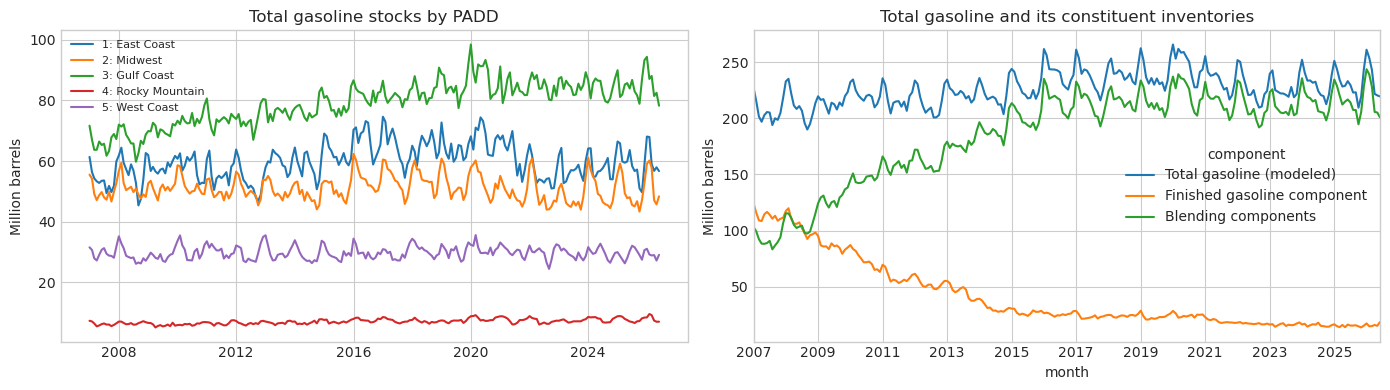

In [8]:
# Compare regional total stocks and the national finished/blending components.
# The modeled target is total gasoline, not finished gasoline alone; /1000
# converts stored thousand barrels into million barrels for plotting.

fig, axes = plt.subplots(1,2,figsize=(14,4))
for p,g in panel.groupby('padd'):
    axes[0].plot(g.month, g.stock_kb/1000, label=f'{p}: {PADD_NAMES[p]}')
context = panel.groupby('month')[['stock_kb','finished_stock_kb','blending_stock_kb']].sum()
(context/1000).rename(columns={'stock_kb':'Total gasoline (modeled)',
    'finished_stock_kb':'Finished gasoline component', 'blending_stock_kb':'Blending components'}).plot(ax=axes[1])
axes[0].set_title('Total gasoline stocks by PADD'); axes[0].legend(fontsize=8)
axes[1].set_title('Total gasoline and its constituent inventories')
for ax in axes: ax.set_ylabel('Million barrels')
plt.tight_layout(); plt.show()

The total stock series matches the sum of finished and blending-component stocks within 1 kb. January 2026 has reported-stock-change versus stock-level discrepancies of +66, -43, and -81 kb in PADDs 1, 3, and 5 respectively; these source differences remain visible. The historical stock levels change substantially over time. A model can obtain a high stock-level R² by following this slow movement while still doing poorly on monthly changes. We therefore select on MAE and compare with persistence, inspect annual folds, and report the recent final test period, excluded from the current model selection.

## 3. What information does a forecast use?

Each row predicts stock in month **t**, using observed stocks and flows only through **t−1**, plus the known calendar month of t. Features include the last stock, the same month's stock a year earlier, the latest stock change, prior-month flows with supply and disposition signs, and calendar terms representing the annual seasonal pattern.

This is a **forecast based on the latest available monthly data**, not a test using the data available on each historical release date. EIA publishes monthly data with a delay and later revises it. The experiment assumes prior-month observations are available; it does not claim that all features were available at the start of each calendar month. July and August 2026 outlook rows are projections beyond June's observed data, even though those calendar months have passed at the time of preparation.

The flow-accounting baseline separately forecasts every target-month flow using only earlier observations: the last 60 non-COVID observations of **daily rates**, a linear trend, and a separate seasonal effect for each calendar month. Rates are multiplied by target-month days. Trade and demand forecasts have a zero floor; net refinery production, adjustments, receipts, and biofuel net production retain their signs. In particular, blending-component net inputs may be negative, indicating net production of blendstocks.

### Build a forecast row from past observations

`forecast_flows` converts monthly volumes to daily rates, fits trend and calendar effects on earlier observations, then converts forecasts back to monthly volumes. `feature_row` reads only the supplied history. `supervised` stops that history immediately before each target month and attaches the target separately.

In [9]:
# Build a trend in years plus 11 calendar-month indicators. January is the
# reference month represented by the regression intercept.
def seasonal_design(months, origin):
    dates = pd.DatetimeIndex(months)
    trend = ((dates.year - origin.year) * 12 + dates.month - origin.month).to_numpy() / 12
    return np.column_stack([trend] + [(dates.month == m).astype(float) for m in range(2, 13)])


# Use only the supplied origin history. The last 60 non-COVID observations may
# span more than 60 calendar months because excluded months are skipped.
def forecast_flows(history, months):
    """Fit monthly daily-rate seasonality + trend on the last 60 observed months."""
    train = history.loc[outside_covid(history.month)].tail(60)
    model = LinearRegression()
    # Fit gasoline flows as daily rates, preventing longer months from appearing
    # artificially stronger. [:, None] broadcasts one day-count divisor across each row.
    model.fit(seasonal_design(train.month, train.month.iloc[0]),
              train[FLOWS].to_numpy() / train.month.dt.days_in_month.to_numpy()[:, None])
    rates = model.predict(seasonal_design(months, train.month.iloc[0]))
    # Convert forecast daily rates back to monthly volumes using target-month day
    # counts, including February and leap years.
    flows = rates * pd.DatetimeIndex(months).days_in_month.to_numpy()[:, None]
    for c in ['demand_kb', 'imports_kb', 'exports_kb']:
        flows[:, FLOWS.index(c)] = np.maximum(flows[:, FLOWS.index(c)], 0)
    # Net refinery production, receipts, adjustments and biofuel net production can be negative.
    return pd.DataFrame(flows, columns=FLOWS, index=pd.DatetimeIndex(months))

In [10]:
# Build target-month inputs from history ending one month earlier. History must
# be sorted, continuous, and contain at least 12 monthly observations.
def feature_row(history, month):
    last = history.iloc[-1]
    # Use prior stock, year-ago stock, and the latest stock change. Sine/cosine encode
    # annual seasonality smoothly across the December/January boundary.
    row = {'stock_lag1': last.stock_kb, 'stock_lag12': history.iloc[-12].stock_kb,
           'change_lag1': last.stock_kb - history.iloc[-2].stock_kb,
           'sin_month': np.sin(2*np.pi*month.month/12), 'cos_month': np.cos(2*np.pi*month.month/12)}
    # Calculate observed changes before filtering; omit any change whose current
    # or previous stock observation falls inside the excluded COVID period.
    changes = history.set_index('month').stock_kb.diff()
    clean = outside_covid(changes.index) & outside_covid(changes.index - pd.DateOffset(months=1))
    changes = changes.loc[clean].tail(60)
    # Average recent eligible changes for the target calendar month; use zero
    # if that month has no usable historical changes.
    seasonal = changes[changes.index.month == month.month].dropna()
    row['seasonal_change'] = float(seasonal.mean()) if len(seasonal) else 0.0
    # Compare the latest stock with earlier same-calendar-month stock levels,
    # excluding the latest observation from its own reference average.
    normal_history = history.iloc[:-1].loc[lambda f: outside_covid(f.month)].tail(60)
    normal = normal_history[normal_history.month.dt.month.eq(last.month.month)].stock_kb
    row['stock_seasonal_gap'] = float(last.stock_kb - normal.mean()) if len(normal) else 0.0
    # Pre-sign prior-month flows so nonnegative regression coefficients retain the
    # supply-versus-demand direction in the constrained model.
    row.update({'lag_' + c: last[c] * sign for c, sign in zip(FLOWS, SIGNS)})
    return row


# Create labeled rows after a 12-month warm-up. Rebuild each feature vector and
# flow-identity benchmark using only history preceding that row's target month.
def supervised(history):
    rows = []
    for i in range(12, len(history)):
        # Keep the target separate: its stock supplies actual_kb/delta_kb only. Actual
        # target-month flows must not become inputs to a prediction of that month.
        past, current = history.iloc[:i], history.iloc[i]
        row = feature_row(past, current.month)
        flow = forecast_flows(past, [current.month]).iloc[0]
        row.update(month=current.month, origin_month=past.month.iloc[-1],
                   actual_kb=current.stock_kb, delta_kb=current.stock_kb-past.stock_kb.iloc[-1],
                   forecast_flow_identity=max(0.0, past.stock_kb.iloc[-1] + flow.to_numpy() @ SIGNS))
        rows.append(row)
    return pd.DataFrame(rows)

In [11]:
# Inspect a few supervised rows to make the forecast origin/target alignment
# concrete. Each origin must precede its target; actual_kb is an outcome only.

example = supervised(panel[panel.padd.eq(1)].reset_index(drop=True))
display(example[['origin_month','month','stock_lag1','stock_lag12','lag_production_kb',
                 'forecast_flow_identity','actual_kb']].tail(5))
assert (example.origin_month < example.month).all()
# Notice: actual_kb is the outcome, never a feature passed to a fitted estimator.

,origin_month,month,stock_lag1,stock_lag12,lag_production_kb,forecast_flow_identity,actual_kb
217,2026-01-01,2026-02-01,"68,046.00","65,816.00","22,814.00","67,817.66","67,907.00"
218,2026-02-01,2026-03-01,"67,907.00","59,836.00","20,737.00","60,730.14","59,053.00"
219,2026-03-01,2026-04-01,"59,053.00","59,440.00","23,537.00","58,491.03","56,752.00"
220,2026-04-01,2026-05-01,"56,752.00","59,838.00","22,717.00","58,933.75","57,919.00"
221,2026-05-01,2026-06-01,"57,919.00","63,611.00","22,503.00","60,201.20","56,678.00"


### How to read the model results

**Mean absolute error (MAE)** is the average size of an inventory forecast miss. **Root mean squared error (RMSE)** gives more weight to large misses. Both are in thousand barrels unless the table says million barrels. Lower is better. **R²** compares squared forecast errors with variation around the test-period average stock level. A negative value means the forecast has more squared error than that average-level comparison; it does not directly measure performance against persistence.

**Persistence** keeps stocks unchanged from the latest observation. **Same month last year** repeats the stock level from twelve months earlier. **Seasonal change** instead adds the typical build or draw for the target calendar month to current stocks. These are three different benchmarks.

A **fold** is one historical test window, fitted on earlier observations. Cross-validation repeats this exercise to choose settings. Because the same development windows help choose the settings and report their scores, those scores may overstate future performance.

A **recursive forecast** projects one month at a time and feeds predicted stocks into the following month. It cannot replace those predictions with actual stocks during the path, so errors can accumulate. A good stock-level score alone does not show that a model predicts the direction of builds and draws well.

## 4. Candidate models and their settings

Each method uses earlier inventories and, where relevant, flows and seasonal patterns to estimate the next stock level. Each PADD is fitted separately.

| Method | What it does |
|---|---|
| Persistence | Keep the latest stock level unchanged. |
| Same month last year | Repeat the inventory level twelve months earlier. |
| Seasonal change | Add the typical build or draw for the forecast month to current stocks. |
| Flow balance | Forecast net supply and add the resulting build or draw to stocks. |
| Constrained regression | Fit prior stocks and signed flows while preserving the specified supply and demand directions. |
| Ridge regression | Fit a linear stock-change relationship while limiting extreme weights. |
| Seasonal ridge | Add variables for the annual seasonal cycle to ridge regression. |
| Polynomial ridge | Allow curved relationships and interactions, with limits on fitted weights. |
| Spline ridge | Allow smooth curves in each input relationship, with limits on fitted weights. |
| Random forest | Average decision trees that relate current conditions to past observations. |
| XGBoost | Build trees in sequence to reduce earlier prediction errors. |
| Neural network | Learn flexible combinations of inputs; flexibility also increases the risk of fitting historical noise. |
| Seasonal-departure regression | Start with the typical seasonal change and estimate a departure using earlier stocks and flows. |
| Robust regression | Reduce the influence of unusually large errors when fitting stock changes. |

Settings are compared on ten chronological development windows. The final two years are excluded from the current search. Lower average barrel error wins; a more complex method receives no preference.

Gasoline selects one-month winners by regional development MAE and then sums their forecasts. Unlike crude, it does not make a second selection on national one-month MAE. A different common model family is selected for the twelve-month outlook using national development-path errors. A fitted relationship describes historical co-movement, not proof of a causal effect.

### Exact model definitions

These constants specify the feature sets. `estimator` declares every learned model and its settings. `fit` chooses stock level or stock change as the target; `predict` converts changes back into levels and implements the simple baselines.

In [12]:
# Baselines carry stocks forward, repeat year-ago stocks, add a seasonal change,
# or accumulate forecast net flows; none needs a fitted stock estimator.
BASELINES = ['persistence', 'seasonal_naive', 'seasonal_change', 'forecast_flow_identity']
# Candidates share forecast timing and evaluation. Names ending in '_change'
# model stock increments, while constrained_level models inventory levels.
LEARNED = ['constrained_level', 'ridge_change', 'seasonal_ridge_change',
           'polynomial_ridge_change', 'spline_ridge_change', 'random_forest_change',
           'xgboost_change', 'neural_network_change']
LEARNED += ['seasonal_residual_change', 'huber_change']
MODELS = BASELINES + LEARNED
BASE_FEATURES = ['stock_lag1', 'stock_lag12', 'change_lag1'] + ['lag_' + c for c in FLOWS]
FEATURES = BASE_FEATURES + ['sin_month', 'cos_month']

In [13]:
# Select predictor columns explicitly. actual_kb and delta_kb are labels and
# must never enter the estimator's input matrix.
def columns(name):
    if name == 'seasonal_residual_change':
        return FEATURES + ['stock_seasonal_gap', 'seasonal_change']
    if name == 'constrained_level':
        return ['stock_lag1'] + ['lag_' + c for c in FLOWS]
    if name == 'ridge_change':
        return BASE_FEATURES
    return FEATURES


# Return an unfitted candidate. Pipeline transformations are learned inside each
# fit, so test observations cannot influence scaling or spline preparation.
def estimator(name):
    if name == 'seasonal_residual_change':
        # Standardize predictors before L2-regularized regression. Larger alpha shrinks
        # coefficients more strongly; grid search overrides these starting defaults.
        return make_pipeline(StandardScaler(), Ridge(alpha=100))
    if name == 'huber_change':
        return TransformedTargetRegressor(regressor=make_pipeline(StandardScaler(),
            # Huber loss reduces outlier influence; the surrounding target transformer
            # scales the response and reverses that scaling when predicting.
            HuberRegressor(max_iter=1000)), transformer=StandardScaler())
    if name == 'constrained_level':
        # Constrain coefficients, not the intercept, to be nonnegative. Pre-signed demand
        # features therefore contribute negatively without imposing a full flow identity.
        return LinearRegression(positive=True)
    if name in ['ridge_change', 'seasonal_ridge_change']:
        # Standardize predictors before L2-regularized regression. Larger alpha shrinks
        # coefficients more strongly; grid search overrides these starting defaults.
        return make_pipeline(StandardScaler(), Ridge(alpha=100))
    if name == 'polynomial_ridge_change':
        # Expand predictors with powers/interactions, rescale, and regularize to control
        # flexibility. The regression supplies the intercept, so no bias column is needed.
        return make_pipeline(StandardScaler(), PolynomialFeatures(2, include_bias=False),
                             StandardScaler(), Ridge(alpha=1000))
    if name == 'spline_ridge_change':
        # Represent each feature using smooth piecewise-polynomial basis functions;
        # linear extrapolation controls behavior outside its observed training range.
        return make_pipeline(SplineTransformer(n_knots=4, degree=2, extrapolation='linear'),
                             StandardScaler(), Ridge(alpha=100))
    if name == 'random_forest_change':
        # Average resampled decision trees. Depth and minimum leaf size limit complexity;
        # the fixed seed makes randomized fitting reproducible.
        return RandomForestRegressor(n_estimators=150, max_depth=4, min_samples_leaf=12,
                                     max_features=0.8, n_jobs=1, random_state=42)
    if name == 'xgboost_change':
        # Boost shallow trees sequentially. Learning rate, regularization, and row/column
        # subsampling control how aggressively the ensemble fits remaining residuals.
        return XGBRegressor(n_estimators=120, max_depth=2, learning_rate=0.03,
            min_child_weight=12, reg_lambda=30, subsample=0.8, colsample_bytree=0.8,
            n_jobs=1, random_state=42, objective='reg:squarederror')
    if name == 'neural_network_change':
        return TransformedTargetRegressor(regressor=make_pipeline(StandardScaler(),
            # Fit a small neural network with LBFGS on scaled inputs and a scaled target.
            # Alpha penalizes weights, and the random seed fixes initialization.
            MLPRegressor(hidden_layer_sizes=(16,), alpha=10, solver='lbfgs',
                         max_iter=3000, random_state=42)), transformer=StandardScaler())
    raise ValueError(name)

In [14]:
# Return (estimator, warning_text). Baselines return None because predict computes
# them directly; learned candidates filter training dates before fitting.
def fit(name, train, params=None):
    if name in BASELINES:
        return None, ''
    train = training_rows(train)
    model = estimator(name)
    if params:
        model.set_params(**params)
    # Choose inventory level or monthly change as response, both in thousand barrels.
    target = 'actual_kb' if name == 'constrained_level' else 'delta_kb'
    # Match the search's numerical settings, including neural-network refits.
    from threadpoolctl import threadpool_limits
    with warnings.catch_warnings(record=True) as caught, threadpool_limits(limits=1):
        warnings.simplefilter('always', ConvergenceWarning)
        # Fit the seasonal-residual candidate to departures from normal seasonal change;
        # predict reconstructs the seasonal component before converting to stock levels.
        values = train[target] - train.seasonal_change if name == 'seasonal_residual_change' else train[target]
        model.fit(train[columns(name)], values)
    return model, '; '.join(str(w.message) for w in caught)


# Return stock levels in kb for every candidate, including change-based models.
# Use identical reconstruction and flooring rules during tuning and forecasting.
def predict(name, model, frame):
    if name == 'persistence':
        return frame.stock_lag1.to_numpy()
    if name == 'seasonal_naive':
        return frame.stock_lag12.to_numpy()
    if name == 'seasonal_change':
        return np.maximum(0, frame.stock_lag1.to_numpy() + frame.seasonal_change.to_numpy())
    if name == 'forecast_flow_identity':
        return frame.forecast_flow_identity.to_numpy()
    prediction = model.predict(frame[columns(name)])
    if name == 'seasonal_residual_change':
        prediction += frame.seasonal_change.to_numpy()
    # Add the predicted increment to prior stock to recover an inventory level.
    if name != 'constrained_level':
        prediction += frame.stock_lag1.to_numpy()
    # Prevent a learned model from producing a negative final stock level.
    return np.maximum(prediction, 0)

In [15]:
# Enumerate tunable combinations. Double underscores address nested pipeline
# parameters; an empty grid indicates a candidate with no parameter search.
def parameter_grid(name):
    """Conventional compact grids for each tunable model family."""
    if name == 'seasonal_residual_change':
        return {'ridge__alpha': [0.1, 1, 10, 100, 1000]}
    if name == 'huber_change':
        return {'regressor__huberregressor__epsilon': [1.35, 1.75],
                'regressor__huberregressor__alpha': [0.01, 1, 10]}
    if name in ['ridge_change', 'seasonal_ridge_change']:
        return {'ridge__alpha': [0.01, 0.1, 1, 10, 100, 1000]}
    if name == 'polynomial_ridge_change':
        return {'polynomialfeatures__degree': [1, 2], 'ridge__alpha': [1, 10, 100, 1000]}
    if name == 'spline_ridge_change':
        return {'splinetransformer__n_knots': [3, 5, 7],
                'splinetransformer__degree': [2, 3], 'ridge__alpha': [1, 100, 1000]}
    if name == 'random_forest_change':
        return {'n_estimators': [100, 200], 'max_depth': [3, 5, None],
                'min_samples_leaf': [5, 12]}
    if name == 'xgboost_change':
        return {'n_estimators': [100, 200], 'max_depth': [2, 4],
                'learning_rate': [0.01, 0.05, 0.1], 'reg_lambda': [1, 30]}
    if name == 'neural_network_change':
        return {'regressor__mlpregressor__hidden_layer_sizes': [(16,), (32,), (32, 16)],
                'regressor__mlpregressor__alpha': [0.01, 1, 10]}
    return {}


# Adapt candidates to sklearn's cloning/search interface. Score reconstructed
# stock levels, including seasonal adjustments, damping, and the zero floor.
class StockRegressor(RegressorMixin, BaseEstimator):
    """Let GridSearchCV score the final stock-level forecast."""
    def __init__(self, name, model):
        self.name = name
        self.model = model

    def fit(self, X, y):
        from sklearn.base import clone
        X = training_rows(X)
        target = X.actual_kb if self.name == 'constrained_level' else X.delta_kb
        if self.name == 'seasonal_residual_change':
            target = target - X.seasonal_change
        # Clone an unfitted candidate for each fold so fitted state cannot leak across
        # search trials. A trailing underscore conventionally marks fitted attributes.
        self.model_ = clone(self.model).fit(X[columns(self.name)], target)
        return self

    def predict(self, X):
        return predict(self.name, self.model_, X)


# Search only the supplied past window; return parameters, all candidate/fold
# scores, and convergence warnings. The chosen estimator is fitted separately.
def tune(name, train, folds=10, jobs=8, splits=None):
    """Search past-only folds and retain every candidate's scores."""
    grid = parameter_grid(name)
    if not grid:
        return {}, pd.DataFrame(), ''
    cv = splits if splits is not None else validation_splits(train, folds)
    # Maximize negative MAE, equivalent to minimizing stock error. model__ reaches
    # the candidate inside StockRegressor; refit=False avoids an unused final fit.
    search = GridSearchCV(StockRegressor(name, estimator(name)),
        {'model__' + key: value for key, value in grid.items()},
        scoring='neg_mean_absolute_error', cv=cv, n_jobs=jobs,
        refit=False, error_score='raise', return_train_score=True)
    from joblib import parallel_backend
    from threadpoolctl import threadpool_limits
    with warnings.catch_warnings(record=True) as caught, threadpool_limits(limits=1), parallel_backend('threading'):
        warnings.simplefilter('always', ConvergenceWarning)
        search.fit(train, train.actual_kb)
    results = pd.DataFrame(search.cv_results_)
    results['params'] = results.params.map(
        lambda p: json.dumps({k.removeprefix('model__'): v for k,v in p.items()}, sort_keys=True))
    # Reverse sklearn's negative-score convention to report positive MAE.
    results['mean_test_mae_kb'] = -results.mean_test_score
    # Remove the wrapper prefix so fit() can set parameters on the candidate itself.
    params = {k.removeprefix('model__'): v for k,v in search.best_params_.items()}
    warning = '; '.join(sorted({str(w.message) for w in caught}))
    return params, results, warning

In [16]:
# Show each candidate's search space before running the experiment; nested
# parameter names identify the relevant estimator or pipeline transformation.

display(pd.DataFrame([{'model':name,'param_grid':parameter_grid(name)} for name in LEARNED]))

,model,param_grid
0,constrained_level,{}
1,ridge_change,"{'ridge__alpha': [0.01, 0.1, 1, 10, 100, 1000]}"
2,seasonal_ridge_change,"{'ridge__alpha': [0.01, 0.1, 1, 10, 100, 1000]}"
3,polynomial_ridge_change,"{'polynomialfeatures__degree': [1, 2], 'ridge_..."
4,spline_ridge_change,"{'splinetransformer__n_knots': [3, 5, 7], 'spl..."
5,random_forest_change,"{'n_estimators': [100, 200], 'max_depth': [3, ..."
6,xgboost_change,"{'n_estimators': [100, 200], 'max_depth': [2, ..."
7,neural_network_change,{'regressor__mlpregressor__hidden_layer_sizes'...
8,seasonal_residual_change,"{'ridge__alpha': [0.1, 1, 10, 100, 1000]}"
9,huber_change,"{'regressor__huberregressor__epsilon': [1.35, ..."


### How errors and national totals are calculated

MAE averages absolute errors; RMSE squares errors before averaging and taking a square root; R² compares squared errors with variation around the evaluation sample mean. `aggregate` checks five distinct PADDs for every key before summing—regional MAEs are never added to obtain national MAE.

In [17]:
# MAE and RMSE are in kb; RMSE weights large misses more. R-squared is unitless
# and may be negative when errors exceed the actual sample's mean-only benchmark.
def score(actual, predicted):
    return {'mae_kb': mean_absolute_error(actual, predicted),
            'rmse_kb': mean_squared_error(actual, predicted)**0.5,
            'r2': r2_score(actual, predicted), 'n': len(actual)}


# Require one row for every PADD in each group before summing additive columns.
# Compute national errors after summation; regional forecast errors can offset.
def aggregate(frame, keys, additive):
    """Reject partial U.S. totals instead of silently summing fewer than five PADDs."""
    if frame.duplicated(keys + ['padd']).any():
        raise ValueError('Duplicate PADD rows in aggregation')
    if not frame.groupby(keys).padd.nunique().eq(5).all():
        raise ValueError('U.S. aggregation requires all five PADDs')
    return frame.groupby(keys, as_index=False)[additive].sum(min_count=5)


# Score each group, expanding either a scalar or tuple group key into the named
# key columns of the resulting metrics table.
def metric_table(predictions, keys):
    return pd.DataFrame([{**dict(zip(keys, k if isinstance(k, tuple) else (k,))),
        **score(g.actual_kb, g.predicted_kb)} for k,g in predictions.groupby(keys)])

### One worked fold, before the full comparison

This small example trains the constrained regression for PADD 1 on the first development training window, predicts the following year, and shows each error. It uses the same `fit`, `predict`, and `score` functions as the full experiment.

In [18]:
# Work through the first expanding-window fold for one PADD with the constrained
# model. This illustrative split uses the raw calendar; the full evaluation
# uses validation_splits for COVID-eligible target dates. fit still filters inputs.

worked = supervised(panel[panel.padd.eq(1)].reset_index(drop=True))
development_example = worked.iloc[:-24]
train_idx, test_idx = next(TimeSeriesSplit(n_splits=10, test_size=12).split(development_example))
train_example, test_example = development_example.iloc[train_idx], development_example.iloc[test_idx]
example_model, example_warning = fit('constrained_level', train_example)
example_predictions = predict('constrained_level', example_model, test_example)
worked_results = test_example[['origin_month','month','actual_kb']].copy()
worked_results['predicted_kb'] = example_predictions
worked_results['absolute_error_kb'] = abs(worked_results.actual_kb-worked_results.predicted_kb)
print('Training targets:',train_example.month.min().date(),'to',train_example.month.max().date())
display(worked_results)
display(pd.Series(score(test_example.actual_kb,example_predictions),name='Worked-fold scores'))
assert train_example.month.max() < test_example.month.min()

Training targets: 2008-01-01 to 2014-06-01


,origin_month,month,actual_kb,predicted_kb,absolute_error_kb
78,2014-06-01,2014-07-01,"59,765.00","60,048.29",283.29
79,2014-07-01,2014-08-01,"57,773.00","58,116.20",343.20
80,2014-08-01,2014-09-01,"55,712.00","57,668.53","1,956.53"
81,2014-09-01,2014-10-01,"50,685.00","55,592.71","4,907.71"
82,2014-10-01,2014-11-01,"53,624.00","51,854.05","1,769.95"
83,2014-11-01,2014-12-01,"62,085.00","57,592.70","4,492.30"
84,2014-12-01,2015-01-01,"69,032.00","63,100.06","5,931.94"
85,2015-01-01,2015-02-01,"68,142.00","66,421.36","1,720.64"
86,2015-02-01,2015-03-01,"64,542.00","61,938.98","2,603.02"
87,2015-03-01,2015-04-01,"63,272.00","61,243.42","2,028.58"


mae_kb    2,447.15
rmse_kb   2,979.55
r2            0.68
n            12.00
Name: Worked-fold scores, dtype: float64

In [19]:
# Inspect estimator definitions and feature columns before fitting. Printed
# objects describe configuration, not learned coefficients or held-out accuracy.

# Inspect any candidate and its exact feature list without opening another notebook.
print('XGBoost features:', columns('xgboost_change'))
print(estimator('xgboost_change'))
print(estimator('neural_network_change'))

XGBoost features: ['stock_lag1', 'stock_lag12', 'change_lag1', 'lag_production_kb', 'lag_demand_kb', 'lag_imports_kb', 'lag_exports_kb', 'lag_net_receipts_kb', 'lag_adjustments_kb', 'lag_biofuels_kb', 'sin_month', 'cos_month']
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
             max_leaves=None, min_child_weight=12, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=120,
             n_jobs=1, num_parallel_tree=None, ...)
TransformedTargetRegressor(regress

## 5. Run the complete experiment

The following cells rebuild all results from the saved source snapshots; they use the saved data unless source refresh is enabled. Grid search can take several minutes. To refresh EIA first, run `python us_snd_model.py --refresh-data` from this directory.

Development validation uses ten successive blocks of 12 eligible test months, with an expanding earlier training set. GridSearchCV selects parameters on these folds. The final 24 months are excluded from every search and from model selection. Within each test block, the selected parameters stay fixed while the previous month's observed information updates, so these are one-step predictions. The forecast-flow baseline refits its seasonal rule using information before each target.

We choose the lowest pooled CV MAE per PADD, **including baselines**. After selection, all candidate models are evaluated on the final test period for comparison; that comparison is not used to change the selected model. Finally, selected models are refitted on all eligible observations for the outlook.

### The chronological evaluation loop

The implementation below fits transformations and models separately in each training fold, collects every out-of-fold prediction, chooses regional winners from development errors, and scores the final period without using it to choose a winner. Warning messages are retained.

In [20]:
# Choose each PADD's one-step candidate on development data, evaluate the fixed
# choices on the last 24 months, then refit winners for the live outlook.
def evaluate(samples, folds=10, holdout=24, jobs=8):
    """Choose models only on development CV; score untouched final 24 months."""
    predictions, fold_metrics, selections, fitted, warning_rows = [], [], [], {}, []
    best_parameters, searches = {}, []
    for padd, frame in samples.items():
        # Reserve the final holdout rows before any tuning or candidate selection.
        development = frame.iloc[:-holdout]
        if len(development) - folds*12 < 36:
            raise ValueError('Need >=36 initial training months plus 10 annual folds and holdout')
        splits = validation_splits(development, folds, test_size=12)
        for name in MODELS:
            params, results, warning = tune(name, development, folds, jobs, splits)
            best_parameters[padd, name] = params
            if not results.empty:
                searches.append(results.assign(padd=padd, model=name, stage='development',
                    train_end=development.month.max()))
                print(f'PADD {padd} {name}: grid MAE {results.mean_test_mae_kb.min():,.1f}; {params}', flush=True)
            if warning:
                warning_rows.append(dict(padd=padd, model=name, stage='grid_search', warning=warning))
            # Reuse tuning folds for development diagnostics; these are selection scores,
            # not independent nested-CV estimates of future generalization.
            for fold, (tr, te) in enumerate(splits, 1):
                train, test = training_rows(development.iloc[tr]), development.iloc[te]
                model, warning = fit(name, train, params)
                pred = predict(name, model, test)
                fold_metrics.append(dict(padd=padd, model=name, fold=fold,
                    train_end=train.month.max(), test_start=test.month.min(), test_end=test.month.max(),
                    train_mae_kb=mean_absolute_error(train.actual_kb, predict(name, model, train)),
                    **score(test.actual_kb, pred)))
                output = test[['month', 'origin_month', 'actual_kb']].copy()
                output['predicted_kb'], output['padd'], output['model'] = pred, padd, name
                output['split'], output['fold'] = 'cv', fold
                predictions.append(output)
                if warning:
                    warning_rows.append(dict(padd=padd, model=name, stage=f'cv_{fold}', warning=warning))
        current = pd.concat(predictions, ignore_index=True)
        current = current[current.padd.eq(padd)]
        # Pool absolute development errors for this PADD across folds and select
        # the lowest mean; no holdout observations enter this comparison.
        losses = current.assign(error=lambda x: abs(x.actual_kb-x.predicted_kb)).groupby('model').error.mean()
        winner = losses.idxmin()
        selections.append(dict(padd=padd, selected_model=winner, cv_mae_kb=losses[winner]))
        for name in MODELS:
            model, warning = fit(name, development, best_parameters[padd, name])
            # This is one-step evaluation: each row uses actual prior-month inputs, while
            # estimator parameters remain fitted on development data for the entire block.
            test = frame.iloc[-holdout:]
            output = test[['month', 'origin_month', 'actual_kb']].copy()
            output['predicted_kb'] = predict(name, model, test)
            output['padd'], output['model'], output['split'], output['fold'] = padd, name, 'holdout', 0
            predictions.append(output)
            if warning:
                warning_rows.append(dict(padd=padd, model=name, stage='holdout', warning=warning))
        # Refit the already chosen winner on all eligible history for future use.
        # This final estimator is separate from the one that produced holdout scores.
        final, warning = fit(winner, frame, best_parameters[padd, winner])
        fitted[padd] = {'name': winner, 'estimator': final}
        if warning:
            warning_rows.append(dict(padd=padd, model=winner, stage='final', warning=warning))
        print(f'PADD {padd}: selected {winner}; CV MAE {losses[winner]:,.1f} kb', flush=True)
    return (pd.concat(predictions, ignore_index=True), pd.DataFrame(fold_metrics),
            pd.DataFrame(selections), fitted,
            pd.DataFrame(warning_rows, columns=['padd','model','stage','warning']),
            best_parameters, pd.concat(searches, ignore_index=True))

### The month-by-month forecast implementation

For a year-long path, forecast all flows using history at the origin. Then predict one stock at a time and append that predicted month to the history used for the next step. The raw balance path and statistical stock path remain separate, with an explicit reconciliation difference.

In [21]:
# Produce a recursive path per district plus national sums. After the origin,
# features depend on predicted stocks/flows, not future actual observations.
def forecast(history, fitted, horizon=12):
    all_paths = []
    for p, state in fitted.items():
        past = history[history.padd.eq(p)].sort_values('month').copy()
        origin = past.month.iloc[-1]
        months = pd.date_range(origin + pd.offsets.MonthBegin(), periods=horizon, freq='MS')
        # Forecast the full flow path once at the origin; do not refit flows each step
        # using synthetic observations appended to the stock path.
        flows = forecast_flows(past, months)
        # Track a separate raw flow-identity path initialized at the last observed stock.
        identity_stock = past.stock_kb.iloc[-1]
        for h, month in enumerate(months, 1):
            previous = past.stock_kb.iloc[-1]
            flow = flows.loc[month]
            balance = flow.to_numpy() @ SIGNS
            # At longer horizons, past contains earlier predicted rows. This is the recursive
            # feedback through which forecast errors can propagate along the path.
            features = feature_row(past, month)
            features['forecast_flow_identity'] = max(0.0, previous + balance)
            stock = float(predict(state['name'], state['estimator'], pd.DataFrame([features]))[0])
            # Keep the raw flow accumulation unclipped so impossible inventory paths remain
            # visible; it can diverge from the statistical stock forecast.
            identity_stock += balance
            row = dict(month=month, origin_month=origin, horizon=h, padd=p,
                padd_name=PADD_NAMES[p], model=state['name'], stock_kb=stock,
                previous_stock_kb=previous, stock_change_kb=stock-previous,
                identity_stock_unclipped_kb=identity_stock, balance_kb=balance,
                # Report statistical stock change minus monthly net supply in kb; this
                # discrepancy is not an extra observed EIA adjustment.
                model_reconciliation_kb=stock-previous-balance,
                supply_kb=flow.production_kb+flow.imports_kb+flow.net_receipts_kb+flow.adjustments_kb+flow.biofuels_kb,
                total_demand_kb=flow.demand_kb+flow.exports_kb, **flow.to_dict())
            all_paths.append(row)
            # Append the predicted row so the next month uses this stock and these flows
            # as its most recent history, without seeing future actual values.
            past = pd.concat([past, pd.DataFrame([row])], ignore_index=True)
    regional = pd.DataFrame(all_paths)
    sums = FLOWS + ['stock_kb', 'previous_stock_kb','stock_change_kb', 'identity_stock_unclipped_kb',
                   'balance_kb','model_reconciliation_kb','supply_kb','total_demand_kb']
    return regional, aggregate(regional, ['month','origin_month','horizon'], sums)


# Select the year-ahead family separately from one-step winners, using complete
# recursive development paths and their national stock errors.
def select_horizon(samples, panel, folds=10, jobs=8):
    """Select a year-ahead model using full forecast paths on earlier non-COVID years."""
    predictions, searches, warning_rows = [], [], []
    development_end = samples[1].month.iloc[-25]
    for cutoff in recursive_origins(development_end):
        for name in MODELS:
            states = {}
            for p in PADD_NAMES:
                # Restrict fitting to targets observed by this simulated forecast origin.
                train = samples[p][samples[p].month.le(cutoff)]
                # Retune using only this origin's past history before generating its full path.
                params, results, warning = tune(name, train, folds, jobs)
                if not results.empty:
                    searches.append(results.assign(padd=p, model=name,
                        stage='recursive_development', train_end=cutoff))
                if warning:
                    warning_rows.append(dict(padd=p, model=name, stage='recursive_grid_search', warning=warning))
                model, warning = fit(name, train, params)
                if warning:
                    warning_rows.append(dict(padd=p, model=name, stage='recursive_cv', warning=warning))
                states[p] = {'name':name, 'estimator':model}
            path, _ = forecast(panel[panel.month.le(cutoff)], states)
            path = path[['padd','month','origin_month','horizon','stock_kb']].rename(columns={'stock_kb':'predicted_kb'})
            # Attach actual stocks only after forecasting, for scoring. one_to_one rejects
            # duplicate month/PADD observations that could otherwise multiply rows.
            path = path.merge(panel[['padd','month','stock_kb']], on=['padd','month'], validate='one_to_one').rename(columns={'stock_kb':'actual_kb'})
            predictions.append(path.assign(model=name))
        print(f'Recursive development origin {cutoff.date()} complete', flush=True)
    predictions = pd.concat(predictions, ignore_index=True)
    national = aggregate(predictions, ['month','origin_month','horizon','model'], ['actual_kb','predicted_kb'])
    # Compare national error across complete development paths to select one common
    # family for all PADDs; individual regional estimators are still fitted separately.
    scores = metric_table(national, ['model']).sort_values(['mae_kb','model'])
    return scores.iloc[0].model, predictions, national, scores, pd.concat(searches, ignore_index=True), pd.DataFrame(warning_rows)

In [22]:
# Run controls: use ten expanding validation folds and eight search workers.
# The worker count controls parallel grid trials; numerical threads are capped
# inside fitting to avoid multiplying the number of active CPU threads.

data_dir=HERE/'data'
output_dir=OUTPUT
folds=10
jobs=8

### 5a. Prepare training rows and compare every candidate

Build one learning table for each PADD. The first twelve months provide the history needed for annual and monthly lagged inputs. The full evaluate function above fits the ten chronological folds, chooses regional winners from development errors, and scores the final 24 months.

In [ ]:
output = Path(output_dir)
# Build chronological supervised samples separately for all five districts,
# then run the full development search, one-step holdout evaluation, and refits.
# This is a computationally expensive cell; progress and warnings are retained.
output.mkdir(parents=True, exist_ok=True)
panel = load_panel(data_dir)
histories = {p: panel[panel.padd.eq(p)].reset_index(drop=True) for p in PADD_NAMES}
samples = {p: supervised(history) for p,history in histories.items()}
predictions, fold_metrics, selection, fitted, fit_warnings, best_parameters, grid_results = evaluate(samples, folds, jobs=jobs)

display(fold_metrics.groupby('model').agg(folds=('fold','count'),test_mae_kb=('mae_kb','mean')))
display(selection)

### 5b. Select separate one-month and year-ahead models

Sum the regional one-month forecasts. Then compare each candidate on six full development-year paths that avoid COVID, tuning only on history available before each path. The lowest national year-ahead error selects the outlook model.

In [ ]:
# Assemble the one-step regional-winner model and score national sums. Select
# the year-ahead family separately on recursive development paths, then refit
# that family for each region to generate the 12-month outlook.

# Label the development-selected regional forecasts as a combined model while
# retaining every original candidate's predictions for comparison.
selected = predictions.merge(selection[['padd','selected_model']], on='padd')
selected = selected[selected.model.eq(selected.selected_model)].copy()
selected['model'] = 'selected_padd_models'
one_month_models = selection.sort_values('padd').set_index('padd').selected_model.to_dict()
one_month_model_label = ' + '.join(dict.fromkeys(one_month_models.values()))
combined = pd.concat([predictions, selected[predictions.columns]], ignore_index=True)
us_predictions = aggregate(combined, ['month','origin_month','model','split','fold'], ['actual_kb','predicted_kb'])
padd_metrics = metric_table(combined, ['padd','model','split'])
us_metrics = metric_table(us_predictions, ['model','split'])
# Generate the next month using the selected one-step estimators. The separate
# year-ahead selection below may choose a different family for the 12-month path.
one_step_regional, one_step_national = forecast(panel, fitted, horizon=1)
year_ahead_model, recursive_cv, us_recursive_cv, horizon_scores, horizon_grids, horizon_warnings = select_horizon(samples, panel, folds, jobs)
grid_results = pd.concat([grid_results, horizon_grids], ignore_index=True)
fit_warnings = pd.concat([fit_warnings, horizon_warnings], ignore_index=True)
# Refit the selected year-ahead family on full eligible history, using parameter
# settings chosen before the holdout; then build the forward 12-month outlook.
horizon_fitted = {}
for p, frame in samples.items():
    model, warning = fit(year_ahead_model, frame, best_parameters[p, year_ahead_model])
    horizon_fitted[p] = {'name':year_ahead_model, 'estimator':model}
    if warning:
        fit_warnings.loc[len(fit_warnings)] = [p, year_ahead_model, 'horizon_final', warning]
regional, national = forecast(panel, horizon_fitted)

display(us_metrics.sort_values(['split','mae_kb']))

### 5c. Test the full month-by-month forecast procedure

At each of two disjoint annual final test period origins, refit the already selected model names using only available history. Generate a complete twelve-month path without updating it with actual future observations. These two paths provide only a limited long-horizon diagnostic.

The selected year-ahead method is also compared with unchanged stocks and the one-month models rolled forward over the same two years.

In [ ]:
# Test two nonoverlapping 12-month paths in the holdout using the same recursion
# as the outlook. Refit at each origin with fixed development-selected settings,
# and compare with persistence and the recursively applied one-step model.

# Two disjoint 12-month paths in the final holdout: same recursive procedure as outlook.
recursive = []
recursive_benchmarks = []
# Use the two annual blocks within the final 24 months, starting 24 and
# 12 months before the final observed date.
for offset in [24, 12]:
    states = {}
    cutoff = panel.month.max() - pd.DateOffset(months=offset)
    for p, state in horizon_fitted.items():
        # Restrict fitting to targets observed by this simulated forecast origin.
        train = samples[p][samples[p].month.le(cutoff)]
        model, warning = fit(state['name'], train, best_parameters[p, state['name']])
        states[p] = {'name': state['name'], 'estimator': model}
        if warning:
            fit_warnings.loc[len(fit_warnings)] = [p, state['name'], 'recursive_holdout', warning]
    path, _ = forecast(panel[panel.month.le(cutoff)], states)
    # Attach actual stocks only after forecasting, for scoring. one_to_one rejects
    # duplicate month/PADD observations that could otherwise multiply rows.
    path = path.merge(panel[['padd','month','stock_kb']], on=['padd','month'], suffixes=('_forecast','_actual'), validate='one_to_one')
    path = path.rename(columns={'stock_kb_forecast':'predicted_kb','stock_kb_actual':'actual_kb'})
    recursive.append(path)
    for label in ['persistence', one_month_model_label]:
        baseline_states = {}
        for p in PADD_NAMES:
            name = 'persistence' if label == 'persistence' else one_month_models[p]
            model, warning = fit(name, samples[p][samples[p].month.le(cutoff)], best_parameters[p, name])
            baseline_states[p] = {'name':name, 'estimator':model}
        baseline, _ = forecast(panel[panel.month.le(cutoff)], baseline_states)
        baseline = baseline[['padd','month','origin_month','horizon','stock_kb']].rename(columns={'stock_kb':'predicted_kb'})
        baseline = baseline.merge(panel[['padd','month','stock_kb']], on=['padd','month'], validate='one_to_one').rename(columns={'stock_kb':'actual_kb'})
        recursive_benchmarks.append(baseline.assign(model=label))
recursive = pd.concat(recursive, ignore_index=True)
us_recursive = aggregate(recursive, ['month','origin_month','horizon'], ['actual_kb','predicted_kb'])

display(metric_table(us_recursive, ['horizon']))

### 5d. Assemble the historical benchmark and latest forecast

Sum the five PADD histories to obtain U.S. supply, demand, and stocks. The latest forecast contains five PADD rows and their U.S. sum.

In [ ]:
# Combine regional history into national totals and show the next-month
# forecast. The latest table contains five PADD rows plus one U.S. reporting row.

# Build national historical totals from all five districts. Ratios, when needed,
# must be recomputed from their summed numerator and denominator.
us_history = aggregate(panel, ['month'], FLOWS+['stock_kb','total_gasoline_stock_kb','finished_stock_kb','blending_stock_kb',
    'finished_production_kb','blending_net_inputs_kb','stock_component_residual_kb','balance_kb','accounting_residual_kb'])
# Use padd=0 as a reporting label for the U.S. total; it is not a sixth region.
latest_us = one_step_national.assign(padd=0, padd_name='United States (sum of PADDs)',
                                                   model=one_month_model_label)
latest = pd.concat([one_step_regional, latest_us], ignore_index=True)

display(us_history.tail(3))
display(latest[['padd','padd_name','month','stock_kb']])

### 5e. Save the complete results and models

The exports retain every prediction, aggregate metric, selected model, and forecast path. Constrained-regression coefficients describe that comparison model; they need not be the coefficients of the selected regional models.

In [ ]:
# Save result tables and fitted models for reporting and reuse. CSVs carry
# readable diagnostics; joblib preserves estimator state; coefficients expose
# the constrained regression's fitted relationship.

# Collect inputs, predictions, scores, selections, and audits under stable names.
# Each name becomes a CSV stem consumed by later reporting cells.
tables = {'padd_monthly_model':panel,'us_monthly_model':us_history,
    'padd_predictions':combined,'us_predictions':us_predictions,'padd_model_metrics':padd_metrics,
    'us_model_metrics':us_metrics,'fold_metrics':fold_metrics,'selected_models':selection,
    'padd_forecast_12m':regional,'us_forecast_12m':national,'latest_forecast':latest,
    'recursive_cv_predictions':recursive_cv, 'us_recursive_cv_predictions':us_recursive_cv,
    'year_ahead_model_cv_metrics':horizon_scores,
    'recursive_benchmark_predictions':pd.concat(recursive_benchmarks, ignore_index=True),
    'recursive_holdout_predictions':recursive,'us_recursive_holdout_predictions':us_recursive,
    'recursive_holdout_metrics':metric_table(recursive,['padd']),
    'us_recursive_horizon_metrics':metric_table(us_recursive,['horizon']), 'fit_warnings':fit_warnings,
    'grid_search_results':grid_results,
    'best_parameters':pd.DataFrame([{'padd':p, 'model':name, 'params':json.dumps(params, sort_keys=True)}
        for (p,name),params in best_parameters.items()])}
# Record target and origin dates plus separate fitting/evaluation eligibility
# flags so readers can inspect exactly which dates the exclusion model affects.
tables['training_sample_audit'] = pd.concat([frame[['month','origin_month']].assign(
    padd=p, training_eligible=frame.index.isin(training_rows(frame).index),
    evaluation_eligible=outside_covid(frame.month)) for p, frame in samples.items()], ignore_index=True)
# Write named result tables without pandas' row index; rerunning replaces files
# with the same names in model_output.
for name, frame in tables.items():
    frame.to_csv(output/f'{name}.csv', index=False)
# Save all final candidate estimators as well as selected models so downstream
# analysis can reproduce predictions without repeating parameter searches.
all_fitted = {}
for p, frame in samples.items():
    for name in MODELS:
        model, warning = fit(name, frame, best_parameters[p, name])
        all_fitted[p, name] = {'name': name, 'estimator': model}
joblib.dump(all_fitted, output/'all_fitted_models.joblib')
joblib.dump(horizon_fitted, output/'fitted_horizon_models.joblib')
joblib.dump(fitted, output/'fitted_models.joblib')
# Export an interpretable constrained-regression coefficient table by PADD.
# These coefficients apply to pre-signed inputs, not unsigned raw demand flows.
coefficients = []
for p, frame in samples.items():
    model, _ = fit('constrained_level', frame)
    coefficients.append({'padd':p,'intercept_kb':model.intercept_,**dict(zip(columns('constrained_level'),model.coef_))})
pd.DataFrame(coefficients).to_csv(output/'constrained_model_coefficients.csv',index=False)

print('Saved',len(tables),'result tables to',output)

### 5f. Record the run configuration

Record data dates, units, software versions, candidate settings, validation design, and limitations directly from this run.

In [ ]:
# Persist machine-readable run documentation alongside result tables. Source
# URLs identify provenance; versions and settings describe the actual run,
# including limitations of revised-history and point-only forecasts.

# Record scope, units, actual data dates, selection rules, limitations, and
# software versions alongside outputs for reproducibility and interpretation.
metadata = {'product':'Total motor gasoline: finished motor gasoline plus motor gasoline blending components',
    'covid_exclusion': {'start':'2020-03-01', 'end':'2021-03-01', 'inclusive':True,
        'method':'Exclude targets and direct lag inputs touching COVID from stock fitting; exclude COVID observations from flow fits and seasonal averages; preserve the full calendar and historical balance.',
        'evaluation':'Exclude COVID target months from development selection; full recursive development years avoid COVID; final 24 months unchanged.'},
    'stock_units':'thousand barrels at month end', 'flow_units':'thousand barrels per calendar month',
    'equation':'S[t] = S[t-1] + (finished refinery/blender net production[t] - blending-component refinery/blender net inputs[t]) + imports[t] + net receipts[t] + adjustments[t] + biofuel net production[t] - product supplied[t] - exports[t] + residual[t]',
    'data_start':str(panel.month.min().date()),'data_end':str(panel.month.max().date()),
    'cv':f'{folds} expanding folds, 12 eligible test months each; final 24 months excluded from selection',
    'holdout_start':str(samples[1].month.iloc[-24].date()),
    'forecast_timing':'One month after latest observed EIA month; conditional on prior monthly data being available. Current revised history, not a real-time release-vintage backtest.',
    'one_month_models':one_month_models,
    'one_month_model_label':one_month_model_label,
    'year_ahead_model':year_ahead_model,
    'horizon_selection':'Lowest national error across six full non-COVID development years; retune using only past observations at each origin',
    'selection':'GridSearchCV per PADD/model on development data; lowest pooled development CV MAE per PADD including baselines; no holdout tuning',
    'hyperparameter_search':{'method':'GridSearchCV', 'folds':folds,
        'scoring':'neg_mean_absolute_error', 'splitter':'TimeSeriesSplit on non-COVID target dates; 12 eligible observations per development block',
        'evaluation':'Development scores reuse tuning folds and are selection scores, not nested CV estimates. Final 24 months excluded from every search.',
        'recursive':'Holdout and final refits freeze parameters selected before the holdout.'},
    'flow_forecast':'Last 60 non-COVID observations, daily rates, linear trend and month fixed effects; net production remains signed',
    'components':'Flows sum finished and blending components; production is finished net production minus blending net inputs; stocks use independently published MGTSTP series',
    'forecast_stock_floor':0, 'uncertainty':'Point forecasts only; no calibrated prediction intervals',
    'recursive_validation':'Two disjoint 12-month holdout paths; refit at each origin; only two errors per horizon',
    'versions':{'python':platform.python_version(),'numpy':np.__version__,'pandas':pd.__version__,
                'sklearn':sklearn.__version__, 'xgboost':xgboost.__version__},
    'sources':['https://www.eia.gov/dnav/pet/pet_sum_snd_d_r10_mbbl_m_cur.htm',
               'https://www.eia.gov/dnav/pet/TblDefs/pet_sum_snd_tbldef2.asp']}
(output/'model_metadata.json').write_text(json.dumps(metadata,indent=2))
# Serialize candidate definitions for inspection; repr describes configuration,
# while the joblib files above preserve actual fitted estimator state.
settings = {name: {'features': columns(name), 'estimator': repr(estimator(name)),
                   'param_grid':parameter_grid(name)}
            for name in LEARNED}
(output/'candidate_models.json').write_text(json.dumps(settings, indent=2))
print(us_metrics[us_metrics.split.eq('holdout')].sort_values('mae_kb').to_string(index=False))

print('Data through:',metadata['data_end'])
print('Fitting warnings:',len(fit_warnings))

In [24]:
folds = tables['fold_metrics']
# Inspect one representative model/PADD because candidates share split dates.
# Here folds is reassigned from the earlier integer setting to the metrics table.
# Assertions require training before testing and development before the holdout.
schedule = folds.query("padd == 1 and model == 'persistence'")[['fold','train_end','test_start','test_end','n']]
display(schedule)
assert (pd.to_datetime(schedule.train_end) < pd.to_datetime(schedule.test_start)).all()
assert pd.to_datetime(schedule.test_end).max() < pd.Timestamp(metadata['holdout_start'])

,fold,train_end,test_start,test_end,n
0,1,2013-05-01,2013-06-01,2014-05-01,12
1,2,2014-05-01,2014-06-01,2015-05-01,12
2,3,2015-05-01,2015-06-01,2016-05-01,12
3,4,2016-05-01,2016-06-01,2017-05-01,12
4,5,2017-05-01,2017-06-01,2018-05-01,12
5,6,2018-05-01,2018-06-01,2019-05-01,12
6,7,2019-05-01,2019-06-01,2021-06-01,12
7,8,2020-02-01,2021-07-01,2022-06-01,12
8,9,2022-06-01,2022-07-01,2023-06-01,12
9,10,2023-06-01,2023-07-01,2024-06-01,12


## 6. Development results and overfitting diagnostics

MAE is the average absolute error in thousand barrels; smaller is better. RMSE penalizes occasional large misses more heavily. The train/test gap helps identify excessive flexibility, although the changing data regime also affects it. The selected combination's CV score is optimistic because it is used for model selection; use the final test period to assess performance on later data.

,padd,selected_model,cv_mae_kb
0,1,seasonal_residual_change,"2,406.06"
1,2,neural_network_change,"1,511.81"
2,3,seasonal_residual_change,"2,073.41"
3,4,random_forest_change,345.96
4,5,random_forest_change,"1,050.34"


### Best parameters for the selected PADD models

,padd,selected_model,cv_mae_kb,params
0,1,seasonal_residual_change,"2,406.06","{""ridge__alpha"": 100}"
1,2,neural_network_change,"1,511.81","{""regressor__mlpregressor__alpha"": 10, ""regressor__mlpregressor__hidden_layer_sizes"": [32, 16]}"
2,3,seasonal_residual_change,"2,073.41","{""ridge__alpha"": 10}"
3,4,random_forest_change,345.96,"{""max_depth"": 5, ""min_samples_leaf"": 12, ""n_estimators"": 200}"
4,5,random_forest_change,"1,050.34","{""max_depth"": 5, ""min_samples_leaf"": 5, ""n_estimators"": 100}"


padd,1,2,3,4,5
model,,,,,
constrained_level,2913.403885,2138.861640,2350.076713,399.682590,1191.054700
forecast_flow_identity,2581.938536,1663.697036,2617.334390,403.372965,1244.472820
huber_change,2823.421747,1558.503198,2135.227305,369.336804,1108.711965
neural_network_change,2709.874511,1511.805799,2192.544672,349.311362,1091.024843
persistence,3303.675000,2375.866667,2453.091667,382.075000,1357.166667
polynomial_ridge_change,2799.748899,1540.444174,2121.850360,357.564042,1098.769342
random_forest_change,2567.431387,1572.129607,2352.774531,345.962995,1050.340472
ridge_change,2848.496454,1709.912984,2106.668849,374.328005,1162.654369
seasonal_change,2542.861667,1603.556667,2569.987500,388.769583,1218.497500


,train_mae_kb,mae_kb,test_minus_train_kb
model,,,
seasonal_residual_change,"1,384.94","1,482.92",97.98
neural_network_change,"1,271.29","1,570.91",299.62
random_forest_change,"1,117.73","1,577.73",459.99
xgboost_change,"1,131.14","1,577.83",446.69
seasonal_ridge_change,"1,347.89","1,583.68",235.79
polynomial_ridge_change,"1,347.89","1,583.68",235.79
huber_change,"1,323.85","1,599.04",275.19
spline_ridge_change,"1,280.69","1,613.01",332.32
ridge_change,"1,424.34","1,640.41",216.07


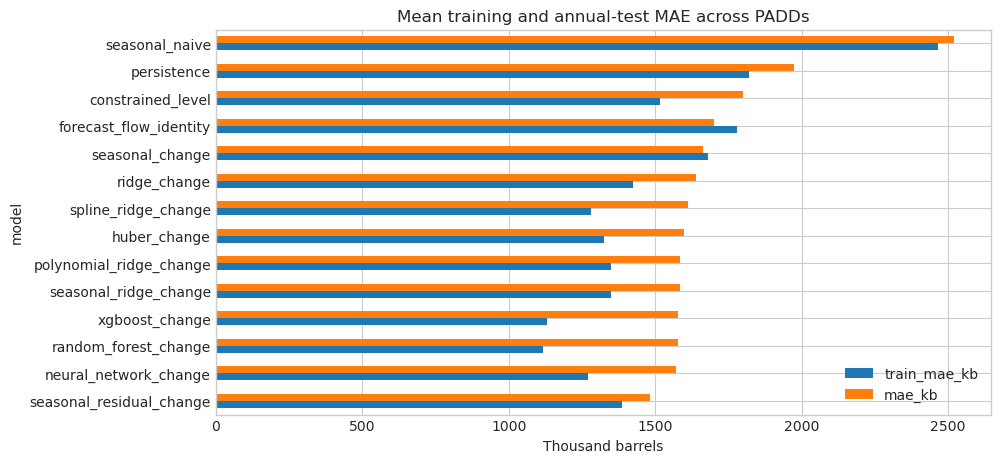

In [25]:
# Compare development MAE by candidate and district, then inspect the average
# train/test gap. A large gap suggests overfitting or a changing data regime;
# these reused selection scores are not an independent performance estimate.

display(tables['selected_models'])
# Join selected family names to their saved per-PADD parameter dictionaries
# so readers can see which settings produced the reported regional winners.
selected_parameters = (tables['selected_models']
    .merge(tables['best_parameters'], left_on=['padd','selected_model'], right_on=['padd','model'])
    [['padd','selected_model','cv_mae_kb','params']])
display(Markdown('### Best parameters for the selected PADD models'))
with pd.option_context('display.max_colwidth',None):
    display(selected_parameters)
cv = tables['padd_model_metrics'].query("split == 'cv' and model != 'selected_padd_models'")
display(cv.pivot(index='model', columns='padd', values='mae_kb').style.highlight_min(axis=0))
gaps = folds.groupby('model')[['train_mae_kb','mae_kb']].mean().sort_values('mae_kb')
# Subtract in-sample MAE from validation MAE; positive gaps mean worse
# performance on later observations than on fitted training observations.
gaps['test_minus_train_kb'] = gaps.mae_kb - gaps.train_mae_kb
display(gaps)
gaps[['train_mae_kb','mae_kb']].plot.barh(figsize=(10,5), title='Mean training and annual-test MAE across PADDs')
plt.xlabel('Thousand barrels'); plt.show()

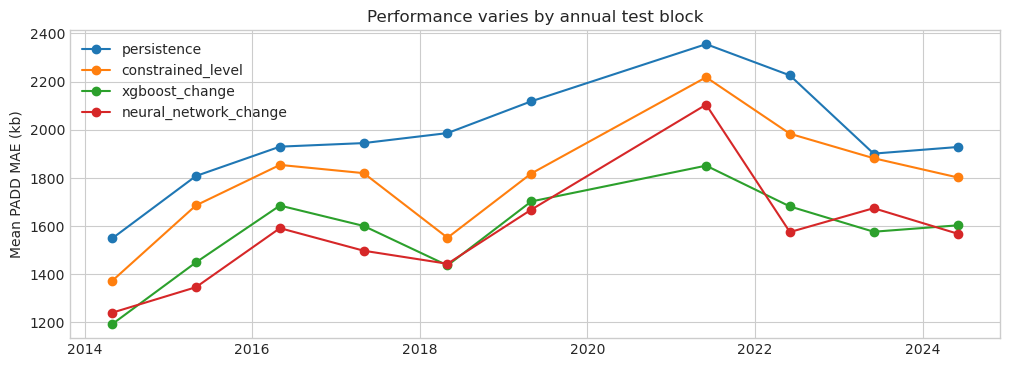

,padd,intercept_kb,stock_lag1,lag_production_kb,lag_demand_kb,lag_imports_kb,lag_exports_kb,lag_net_receipts_kb,lag_adjustments_kb,lag_biofuels_kb
0,1,-982.63,0.59,0.66,0.20,0.24,0.56,0.45,0.45,0.00
1,2,"6,408.44",0.65,0.49,0.32,0.00,0.27,0.39,0.23,0.00
2,3,"30,804.07",0.49,0.29,0.17,0.00,0.00,0.31,0.00,0.00
3,4,"1,238.70",0.70,0.21,0.12,0.00,0.00,0.03,0.00,0.00
4,5,"15,871.19",0.49,0.38,0.41,0.35,0.00,0.47,0.04,0.00


In [26]:
# Group validation errors by test-block endpoint to show regime variation.
# These plotted values average regional MAEs, not errors on national stock sums.
# The coefficient CSV provides a separate view of the constrained model.

fig, ax = plt.subplots(figsize=(12,4))
for name in ['persistence','constrained_level','xgboost_change','neural_network_change']:
    g = folds[folds.model.eq(name)].groupby('test_end').mae_kb.mean()
    ax.plot(pd.to_datetime(g.index), g.values, marker='o', label=name)
ax.set(title='Performance varies by annual test block', ylabel='Mean PADD MAE (kb)')
ax.legend(); plt.show()
display(pd.read_csv(OUTPUT / 'constrained_model_coefficients.csv'))

## 7. Final test period: does the selected model improve on unchanged stocks?

U.S. errors are computed **after summing all five PADD predictions** for the same month. They are not sums of regional MAEs. Regional errors can offset, so selecting the best regional models need not select the best national combination.

In [27]:
# Report the selected PADD combination against persistence on national holdout
# MAE. A positive improvement means lower error. Also identify the best observed
# holdout candidate for context without using hindsight to change the selection.

national_scores = tables['us_model_metrics'].query("split == 'holdout'").sort_values('mae_kb')
display(national_scores.assign(model=national_scores.model.replace(
    {'selected_padd_models': metadata['one_month_model_label']})))
selected_names = tables['selected_models'][['padd','selected_model']]
regional_scores = tables['padd_model_metrics'].query("split == 'holdout'").merge(selected_names, on='padd')
regional_scores = regional_scores[regional_scores.model.eq('persistence') | regional_scores.model.eq(regional_scores.selected_model)]
display(regional_scores[['padd','model','mae_kb','rmse_kb','r2']])
selected_mae = national_scores.set_index('model').loc['selected_padd_models','mae_kb']
naive_mae = national_scores.set_index('model').loc['persistence','mae_kb']
improvement = 100*(1-selected_mae/naive_mae)
best_holdout = national_scores.iloc[0]
display(Markdown(f"**Finding:** Selected PADD models produce a U.S. holdout MAE of **{selected_mae:,.0f} kb** "
    f"versus **{naive_mae:,.0f} kb** for unchanged stocks: **{improvement:.1f}% improvement**. "
    f"The lowest observed national holdout MAE belongs to `{metadata['one_month_model_label'] if best_holdout.model == 'selected_padd_models' else best_holdout.model}` "
    f"({best_holdout.mae_kb:,.0f} kb), but that hindsight result is not used to switch the model. "
    "Historical inventory accuracy does not establish a reliable trading edge."))

,model,split,mae_kb,rmse_kb,r2,n
17,seasonal_change,holdout,"3,426.41","5,092.55",0.85,24
3,forecast_flow_identity,holdout,"3,618.04","5,391.23",0.83,24
21,seasonal_residual_change,holdout,"3,670.53","5,181.12",0.84,24
13,random_forest_change,holdout,"3,783.17","5,546.13",0.82,24
29,xgboost_change,holdout,"4,182.90","5,889.52",0.80,24
25,seasonal_residual_change + neural_network_chan...,holdout,"4,207.50","5,618.73",0.82,24
7,neural_network_change,holdout,"4,350.48","6,236.63",0.77,24
27,spline_ridge_change,holdout,"4,433.60","5,851.38",0.80,24
5,huber_change,holdout,"4,507.34","6,530.22",0.75,24
23,seasonal_ridge_change,holdout,"4,692.84","6,622.54",0.75,24


,padd,model,mae_kb,rmse_kb,r2
4,1,persistence,"3,407.58","4,606.56",0.01
10,1,seasonal_residual_change,"2,041.47","2,487.75",0.71
18,2,neural_network_change,"1,637.79","2,303.24",0.81
19,2,persistence,"3,016.88","3,877.04",0.45
34,3,persistence,"3,304.79","4,089.56",0.05
40,3,seasonal_residual_change,"2,688.82","3,394.22",0.35
49,4,persistence,467.62,645.18,0.45
51,4,random_forest_change,362.99,541.43,0.61
64,5,persistence,"1,389.08","1,557.95",0.00
66,5,random_forest_change,"1,000.05","1,227.69",0.38


**Finding:** Selected PADD models produce a U.S. holdout MAE of **4,208 kb** versus **8,469 kb** for unchanged stocks: **50.3% improvement**. The lowest observed national holdout MAE belongs to `seasonal_change` (3,426 kb), but that hindsight result is not used to switch the model. Historical inventory accuracy does not establish a reliable trading edge.

In [28]:
# Summarize eligible dates and check that fitting excludes COVID target months.
# Optional comparison CSVs show earlier refits on matching dates when available.

audit = tables['training_sample_audit']
display(audit.groupby('padd').agg(total_target_months=('training_eligible','size'),
    eligible_stock_training_months=('training_eligible','sum'), evaluation_months=('evaluation_eligible','sum')))
assert not audit.loc[audit.training_eligible, 'month'].between(COVID_START, COVID_END).any()
# Display prior-run comparison files only when available; these optional reports
# are read here and are not recomputed by this cell.
comparison_file = OUTPUT/'refit_comparison.csv'
if comparison_file.exists():
    display(pd.read_csv(comparison_file))
addition_file = OUTPUT/'candidate_addition_comparison.csv'
if addition_file.exists():
    display(pd.read_csv(addition_file))
year_comparison = OUTPUT/'year_ahead_refit_comparison.csv'
if year_comparison.exists():
    display(Markdown('**Year-ahead comparison on the same forecast dates and origins**'))
    display(pd.read_csv(year_comparison))

,total_target_months,eligible_stock_training_months,evaluation_months
padd,,,
1,222,197,209
2,222,197,209
3,222,197,209
4,222,197,209
5,222,197,209


,region,previous_mae_kb,refit_mae_kb,improvement_pct,test_months
0,U.S.,"4,532.35","4,207.50",7.17,24
1,PADD 1,"2,680.72","2,041.47",23.85,24
2,PADD 2,"1,611.69","1,637.79",-1.62,24
3,PADD 3,"2,710.12","2,688.82",0.79,24
4,PADD 4,342.21,362.99,-6.07,24
5,PADD 5,"1,061.09","1,000.05",5.75,24


,candidate_set,period,mae_kb
0,"Original candidates, COVID excluded",cv,"4,276.59"
1,"Original candidates, COVID excluded",holdout,"4,105.54"
2,"Expanded candidates, COVID excluded",cv,"3,938.82"
3,"Expanded candidates, COVID excluded",holdout,"4,207.50"


**Year-ahead comparison on the same forecast dates and origins**

,region,previous_mae_kb,refit_mae_kb,improvement_pct,forecast_observations
0,U.S.,"6,148.94","5,640.90",8.26,24
1,PADD 1,"3,807.25","3,536.11",7.12,24
2,PADD 2,"1,962.53","1,826.36",6.94,24
3,PADD 3,"3,315.85","2,847.06",14.14,24
4,PADD 4,512.41,688.47,-34.36,24
5,PADD 5,"1,742.95","1,645.68",5.58,24


### Regional forecast review

The table below compares the refitted forecasts against unchanged stocks on the same final 24 months. Positive benchmark improvement means the model adds value; negative means it loses. Average bias shows whether it tends to forecast stocks too high or too low. Error as a share of regional stocks helps compare different-sized inventory pools. The charts show whether misses persist or are concentrated in a few months.

,PADD,Average error (kb),Error / average stocks (%),Improvement over unchanged stocks (%),Average bias (kb),Worst month,Largest miss (kb)
0,1,"2,041.47",3.45,40.09,"-1,005.16",2026-01-01,"5,559.09"
1,2,"1,637.79",3.29,45.71,624.56,2026-04-01,"7,256.84"
2,3,"2,688.82",3.19,18.64,"1,522.94",2025-02-01,"7,560.41"
3,4,362.99,4.66,22.38,-0.34,2026-04-01,"1,576.80"
4,5,"1,000.05",3.43,28.01,156.82,2025-11-01,"2,906.02"


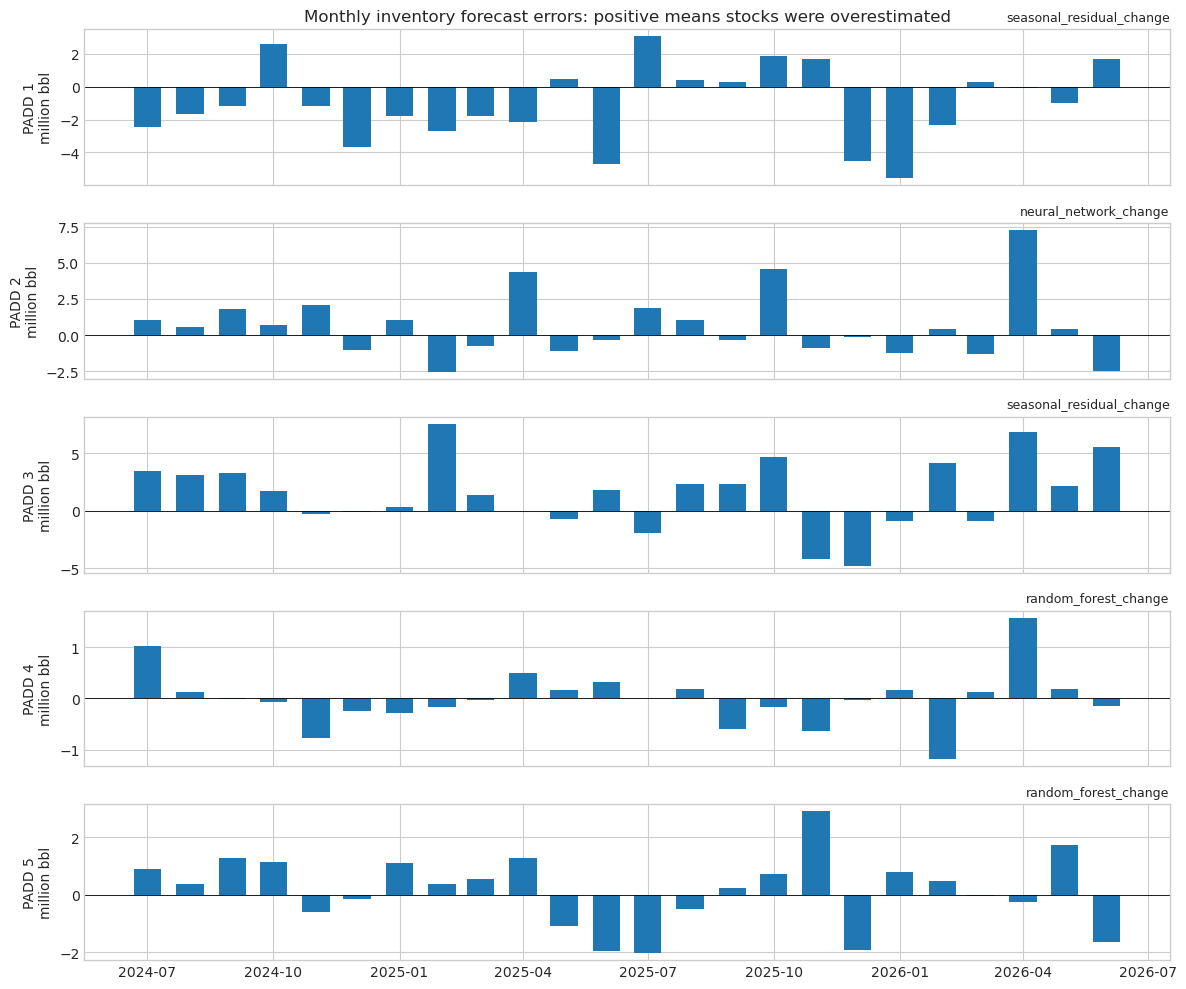

In [29]:
# Compare regional selected-model errors with unchanged stocks on the same
# holdout dates. Normalize MAE by average actual stocks to compare PADD sizes;
# positive percentage improvement means lower error than the benchmark.

# Compare like-for-like regional errors on the same final 24 months.
regional_test = tables['padd_predictions'].query("split == 'holdout'")
selected_names = tables['selected_models'][['padd','selected_model']]
regional_selected = regional_test.merge(selected_names, on='padd')
regional_selected = regional_selected[regional_selected.model.eq(regional_selected.selected_model)]
rows = []
for padd, g in regional_selected.groupby('padd'):
    baseline = regional_test[regional_test.padd.eq(padd) & regional_test.model.eq('persistence')]
    # Align selected and persistence forecasts on the same month within this PADD.
    # Validate unique matches so benchmark improvement is a like-for-like comparison.
    paired = g.merge(baseline[['month','predicted_kb']], on='month', suffixes=('', '_unchanged'), validate='one_to_one')
    # Positive signed error means overestimated stocks; absolute error measures
    # miss size, while mean signed error below measures systematic bias.
    error = paired.predicted_kb - paired.actual_kb
    baseline_mae = (paired.predicted_kb_unchanged - paired.actual_kb).abs().mean()
    # Keep the row label of the largest absolute miss to retrieve its calendar month.
    worst = error.abs().idxmax()
    rows.append({'PADD': padd, 'Average error (kb)': error.abs().mean(),
        'Error / average stocks (%)': 100 * error.abs().mean() / paired.actual_kb.mean(),
        'Improvement over unchanged stocks (%)': 100 * (1 - error.abs().mean() / baseline_mae),
        'Average bias (kb)': error.mean(), 'Worst month': paired.loc[worst, 'month'],
        'Largest miss (kb)': error.abs().max()})
regional_review = pd.DataFrame(rows)
display(regional_review)
# Persist regional diagnostics; charts convert kb to million barrels by /1000.
regional_review.to_csv(OUTPUT/'regional_error_review.csv', index=False)
fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
for ax, (padd, g) in zip(axes, regional_selected.groupby('padd')):
    ax.bar(g.month, (g.predicted_kb-g.actual_kb)/1000, width=20)
    ax.axhline(0, color='black', linewidth=.6)
    ax.set_ylabel(f'PADD {padd}\nmillion bbl')
    ax.set_title(g.selected_model.iloc[0], fontsize=9, loc='right')
axes[0].set_title('Monthly inventory forecast errors: positive means stocks were overestimated')
plt.tight_layout(); plt.show()

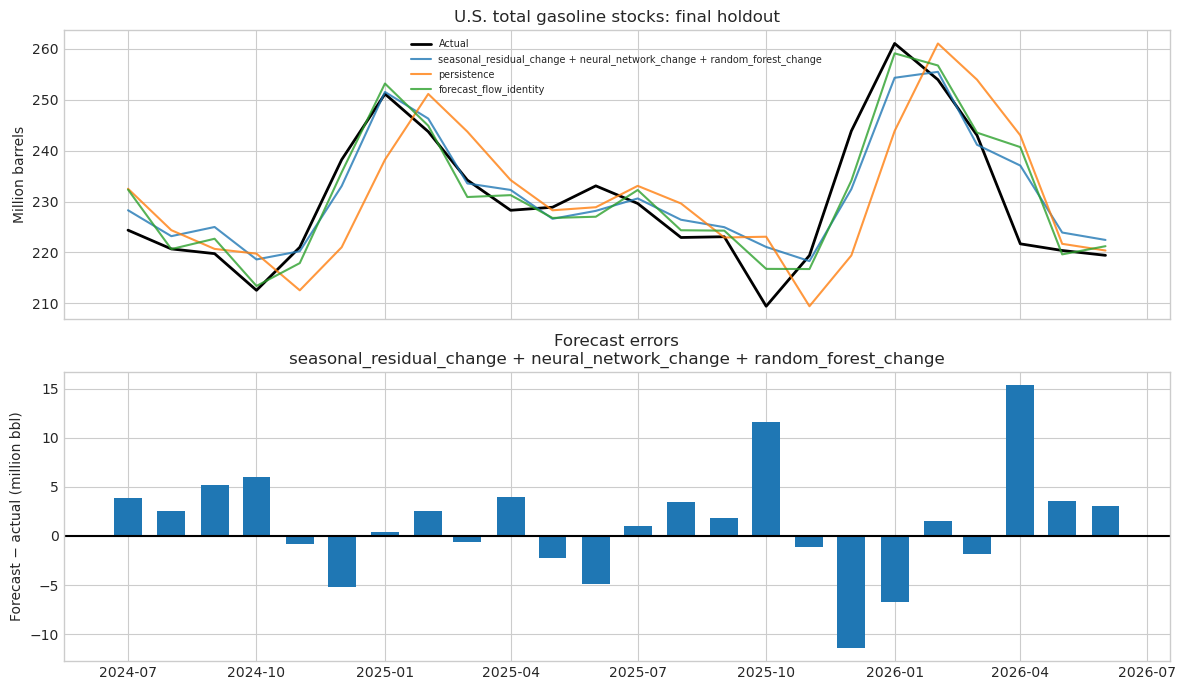

In [30]:
# Use one model's actual column to plot national stocks once, then overlay
# candidate forecasts and signed selected-model errors. Divide kb by 1000
# for million-barrel axes; a positive error bar means excess predicted stocks.

predictions = tables['us_predictions']
holdout = predictions[predictions.split.eq('holdout')]
fig, axes = plt.subplots(2,1,figsize=(12,7),sharex=True)
actual = holdout[holdout.model.eq('selected_padd_models')]
axes[0].plot(actual.month,actual.actual_kb/1000,color='black',label='Actual',linewidth=2)
for name in ['selected_padd_models','persistence','forecast_flow_identity']:
    g = holdout[holdout.model.eq(name)]
    label = metadata['one_month_model_label'] if name == 'selected_padd_models' else name
    axes[0].plot(g.month,g.predicted_kb/1000,label=label,alpha=.8)
axes[0].set(ylabel='Million barrels',title='U.S. total gasoline stocks: final holdout'); axes[0].legend(fontsize=7)
axes[1].bar(actual.month,(actual.predicted_kb-actual.actual_kb)/1000,width=20)
axes[1].axhline(0,color='black'); axes[1].set(ylabel='Forecast − actual (million bbl)',title=f"Forecast errors\n{metadata['one_month_model_label']}")
plt.tight_layout(); plt.show()

## 8. Test the full 12-month forecasting procedure

One-step tests update with actual history each month; a 12-month outlook cannot do that. Here we test two disjoint 12-month paths covering the final test period. Selected model names remain fixed from development CV. Each path refits on history available at its origin, forecasts flows, and feeds predicted stocks and flows forward month by month.

Only **two forecast paths** support this diagnostic. There are just two U.S. errors at each horizon, insufficient for calibrated uncertainty intervals or a strong claim about long-horizon skill.

,model,mae_kb,rmse_kb,r2,n
0,xgboost_change,"6,148.45","7,488.24",0.57,72
1,huber_change,"6,471.91","8,255.01",0.48,72
2,random_forest_change,"6,528.86","7,956.32",0.52,72
3,neural_network_change,"6,670.69","8,346.93",0.47,72
4,seasonal_residual_change,"6,879.57","8,300.21",0.47,72
5,seasonal_ridge_change,"7,017.09","8,832.59",0.41,72
6,constrained_level,"7,161.71","8,701.72",0.42,72
7,spline_ridge_change,"7,621.95","9,214.59",0.35,72
8,seasonal_naive,"7,754.90","9,720.72",0.28,72
9,polynomial_ridge_change,"7,799.44","9,643.16",0.29,72


Year-ahead model selected on development forecasts: xgboost_change


,model,mae_kb,rmse_kb,r2,n
0,persistence,"11,576.96","13,390.48",-0.04,24
1,seasonal_residual_change + neural_network_chan...,"6,137.41","7,493.91",0.67,24
2,xgboost_change,"5,640.90","6,821.24",0.73,24


,padd,model,mae_kb,rmse_kb,r2,n
0,1,persistence,"5,579.54","6,392.88",-0.90,24
1,1,seasonal_residual_change + neural_network_chan...,"5,585.11","6,402.27",-0.91,24
2,1,xgboost_change,"3,536.11","4,348.15",0.12,24
3,2,persistence,"4,113.62","5,451.28",-0.09,24
4,2,seasonal_residual_change + neural_network_chan...,"2,021.74","2,584.47",0.76,24
5,2,xgboost_change,"1,826.36","2,131.49",0.83,24
6,3,persistence,"3,973.50","4,711.83",-0.26,24
7,3,seasonal_residual_change + neural_network_chan...,"3,188.72","3,858.00",0.16,24
8,3,xgboost_change,"2,847.06","3,423.48",0.34,24
9,4,persistence,771.92,"1,004.30",-0.34,24


,padd,mae_kb,rmse_kb,r2,n
0,1,"3,536.11","4,348.15",0.12,24
1,2,"1,826.36","2,131.49",0.83,24
2,3,"2,847.06","3,423.48",0.34,24
3,4,688.47,843.53,0.05,24
4,5,"1,645.68","1,943.81",-0.56,24


,horizon,mae_kb,rmse_kb,r2,n
0,1,"3,338.87","4,033.00",-1.36,2
1,2,"5,451.61","5,536.27",-23.37,2
2,3,"4,153.40","4,245.08",-5.54,2
3,4,"11,025.52","11,412.67",-52.32,2
4,5,"9,009.03","9,299.65",-132.13,2
5,6,"1,902.85","2,172.41",0.41,2
6,7,"7,683.63","8,548.78",-1.98,2
7,8,"5,385.88","7,285.93",-1.04,2
8,9,"5,241.68","7,071.77",-1.59,2
9,10,"2,914.84","3,997.87",-0.47,2


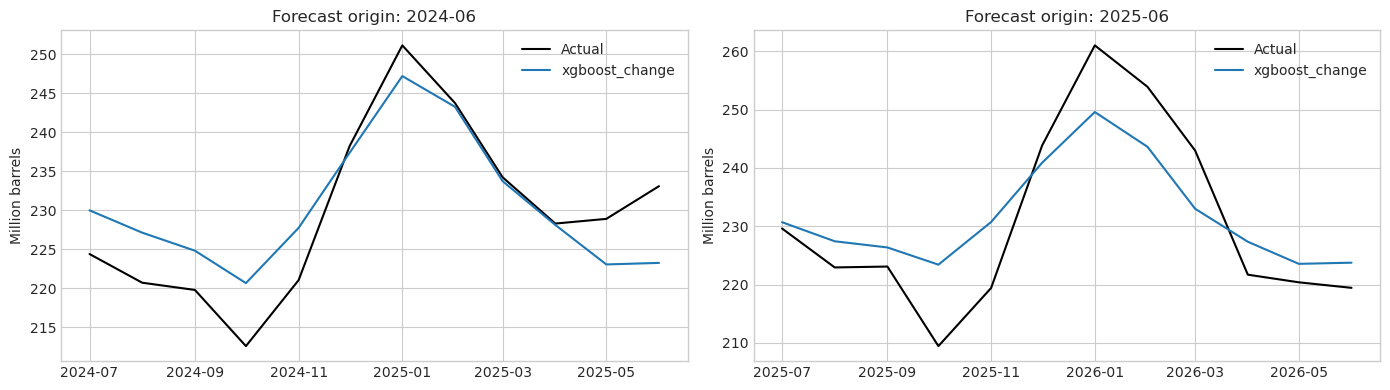

In [31]:
# Compare the development-selected year-ahead family with recursive benchmarks,
# scoring after national aggregation. Each horizon has only two
# path observations here; the plots show those two forecast origins separately.

display(tables['year_ahead_model_cv_metrics'])
print('Year-ahead model selected on development forecasts:', metadata['year_ahead_model'])
bench = tables['recursive_benchmark_predictions']
chosen = tables['recursive_holdout_predictions'].copy()
chosen['model'] = metadata['year_ahead_model']
paths = pd.concat([bench, chosen[bench.columns]], ignore_index=True)
us_paths = aggregate(paths, ['month','origin_month','horizon','model'], ['actual_kb','predicted_kb'])
display(metric_table(us_paths,['model']))
display(metric_table(paths,['padd','model']))

recursive = tables['us_recursive_holdout_predictions']
display(tables['recursive_holdout_metrics'])
display(tables['us_recursive_horizon_metrics'])
fig, axes = plt.subplots(1,2,figsize=(14,4))
for (origin,g),ax in zip(recursive.groupby('origin_month'),axes):
    ax.plot(g.month,g.actual_kb/1000,label='Actual',color='black')
    ax.plot(g.month,g.predicted_kb/1000,label=metadata['year_ahead_model'])
    ax.set(title=f'Forecast origin: {origin:%Y-%m}',ylabel='Million barrels'); ax.legend()
plt.tight_layout(); plt.show()

## 9. Twelve-month supply-and-demand outlook

Flow forecasts use the same trailing seasonal/trend rule as the backtest. Selected statistical stock models use prior-month inputs month by month. The **raw identity stock path** accumulates the projected flow balance. The **selected stock path** need not satisfy that balance exactly, so we export `model_reconciliation_kb = predicted stock change − forecast flow balance`. It is a visible model discrepancy, not a newly observed EIA supply adjustment. The raw identity is left unclipped to expose impossible inventory paths if they arise.

U.S. supply includes net production, imports, net receipts, published adjustments, and biofuel net production; total disposition is domestic product supplied plus exports. Net receipts cancel across PADDs in these data. No price, weather, refinery-outage, regulatory, or macroeconomic scenarios are assumed beyond the fitted historical paths.

,month,production_kb,imports_kb,demand_kb,exports_kb,adjustments_kb,balance_kb,stock_kb,identity_stock_unclipped_kb,model_reconciliation_kb
0,2026-07-01,"283,420.44","20,924.24","282,345.05","26,409.35","1,221.09","-2,984.03","217,153.49","216,456.97",696.52
1,2026-08-01,"284,033.04","21,119.64","285,183.65","26,615.95","1,116.49","-5,316.83","216,039.69","211,140.14","4,203.03"
2,2026-09-01,"274,602.14","18,129.34","267,452.30","25,445.17",697.01,725.71,"215,308.83","211,865.85","-1,456.58"
3,2026-10-01,"281,101.44","14,102.44","278,402.05","26,921.15","2,089.89","-7,833.03","213,030.25","204,032.82","5,554.45"
4,2026-11-01,"287,758.14","14,597.34","265,572.30","31,358.97","1,659.81","7,257.71","222,179.29","211,290.53","1,891.33"
5,2026-12-01,"301,164.24","17,356.41","271,929.45","33,203.75","1,688.49","15,230.74","234,445.35","226,521.27","-2,964.68"
6,2027-01-01,"284,511.24","12,709.64","256,063.05","27,418.55","1,437.29","15,323.57","246,245.80","241,844.84","-3,523.12"
7,2027-02-01,"246,669.32","12,753.17","242,057.78","23,186.43",915.95,"-4,762.51","244,548.55","237,082.33","3,065.26"
8,2027-03-01,"274,655.04","15,028.24","276,444.45","26,285.95","1,564.09","-11,306.43","235,442.30","225,775.90","2,200.17"
9,2027-04-01,"263,685.74","19,544.14","267,680.10","23,653.77",550.81,"-7,368.49","231,419.97","218,407.42","3,346.16"


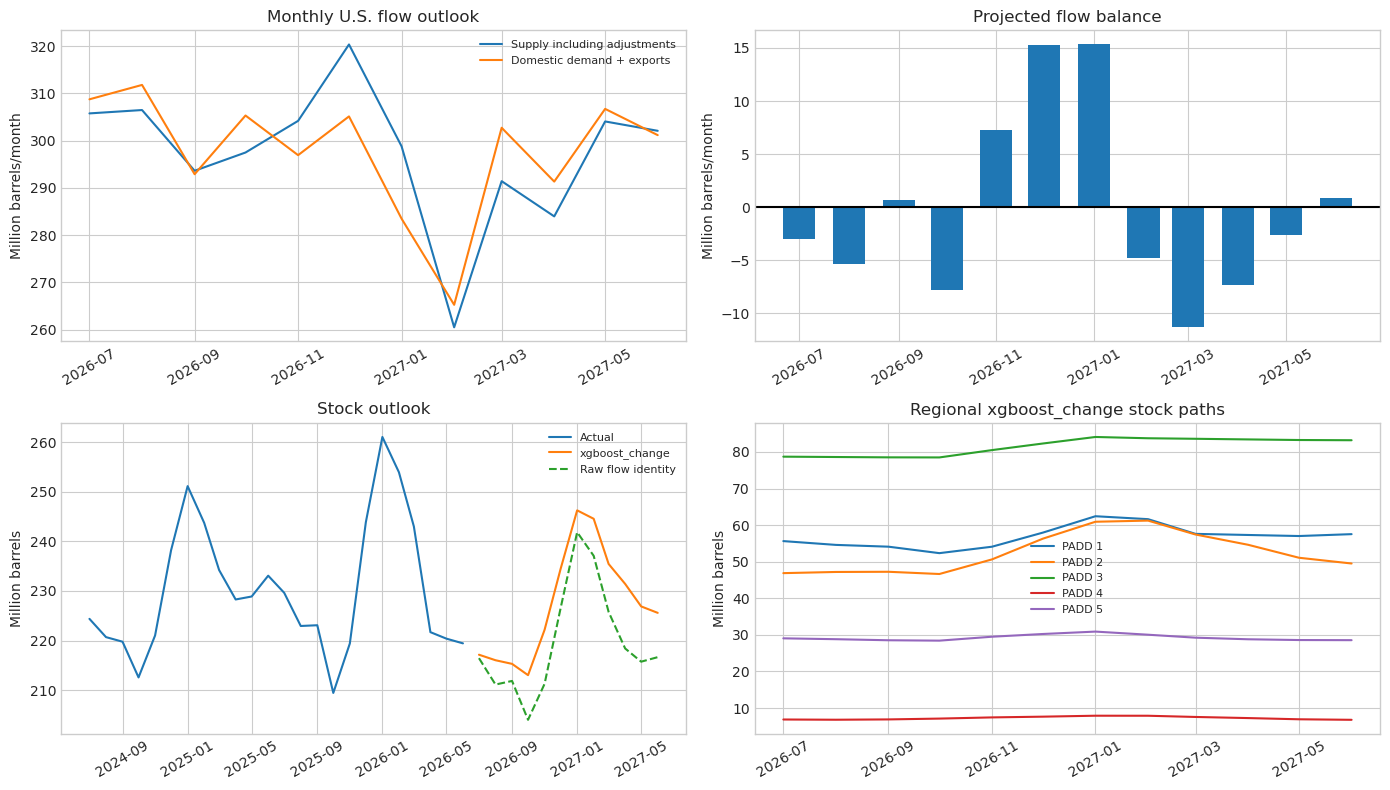

In [32]:
# Plot the conditional 12-month flow and stock outlook. The statistical stock
# path and raw accumulated flow identity need not coincide: reconciliation
# measures predicted stock change minus forecast net supply, not an observed flow.

outlook = tables['us_forecast_12m']
display(outlook[['month','production_kb','imports_kb','demand_kb','exports_kb','adjustments_kb',
                 'balance_kb','stock_kb','identity_stock_unclipped_kb','model_reconciliation_kb']])
fig, axes = plt.subplots(2,2,figsize=(14,8))
for c,label in [('supply_kb','Supply including adjustments'),('total_demand_kb','Domestic demand + exports')]:
    axes[0,0].plot(outlook.month,outlook[c]/1000,label=label)
axes[0,0].set(title='Monthly U.S. flow outlook',ylabel='Million barrels/month'); axes[0,0].legend(fontsize=8)
axes[0,1].bar(outlook.month,outlook.balance_kb/1000,width=20)
axes[0,1].axhline(0,color='black'); axes[0,1].set(title='Projected flow balance',ylabel='Million barrels/month')
recent = tables['us_monthly_model'].tail(24)
axes[1,0].plot(recent.month,recent.stock_kb/1000,label='Actual')
axes[1,0].plot(outlook.month,outlook.stock_kb/1000,label=metadata['year_ahead_model'])
axes[1,0].plot(outlook.month,outlook.identity_stock_unclipped_kb/1000,label='Raw flow identity',linestyle='--')
axes[1,0].set(title='Stock outlook',ylabel='Million barrels'); axes[1,0].legend(fontsize=8)
for p,g in tables['padd_forecast_12m'].groupby('padd'):
    axes[1,1].plot(g.month,g.stock_kb/1000,label=f'PADD {p}')
axes[1,1].set(title=f"Regional {metadata['year_ahead_model']} stock paths",ylabel='Million barrels'); axes[1,1].legend(fontsize=8)
for ax in axes.flat: ax.tick_params(axis='x',rotation=30)
plt.tight_layout(); plt.show()

## 10. Conclusions: what the results mean for the balance

The scorecards below compare forecasts on the same national inventories, dates, and origins. The one-month test contains 24 months. The gasoline year-ahead check uses two disjoint annual paths, with only two observations per horizon. That is a small sample for judging performance across market conditions.

Gasoline's seasonal build-and-draw pattern is a useful starting point, but predicting a stock level is not the same as explaining why demand or refinery output changed. Product supplied is derived from the balance; historical accounting closure alone does not prove demand-forecasting skill.

The selected regional mix and the best national model observed after the test are reported separately. This distinction matters when assessing what could have been chosen using the development results alone.

### One-month national results

,MAE (million bbl),RMSE (million bbl),R²,Forecast observations,Bias (million bbl),MAE improvement vs persistence (%),MAE improvement vs year ago (%)
model,,,,,,,
seasonal_change,3.43,5.09,0.85,24,0.48,59.54,28.21
forecast_flow_identity,3.62,5.39,0.83,24,0.93,57.28,24.20
seasonal_residual_change,3.67,5.18,0.84,24,0.88,56.66,23.10
random_forest_change,3.78,5.55,0.82,24,0.84,55.33,20.74
xgboost_change,4.18,5.89,0.80,24,0.81,50.61,12.36
selected_padd_models,4.21,5.62,0.82,24,1.30,50.32,11.85
neural_network_change,4.35,6.24,0.77,24,0.73,48.63,8.85
spline_ridge_change,4.43,5.85,0.80,24,0.76,47.65,7.11
huber_change,4.51,6.53,0.75,24,-0.49,46.78,5.57


### Twelve-month path results

,MAE (million bbl),RMSE (million bbl),R²,Forecast observations,Bias (million bbl),MAE improvement vs persistence (%),MAE improvement vs year ago (%)
model,,,,,,,
seasonal_naive,4.77,5.92,0.80,24,0.22,58.77,0.00
xgboost_change,5.64,6.82,0.73,24,0.95,51.27,-18.18
seasonal_residual_change + neural_network_change + random_forest_change,6.14,7.49,0.67,24,-2.38,46.99,-28.59
persistence,11.58,13.39,-0.04,24,2.64,0.00,-142.55


The lowest observed one-month MAE belongs to **`seasonal_change`** at **3.43 million barrels**. The method selected before the final test is **`selected_padd_models`**. A winner identified after reviewing this test is a comparison result, not a new selection rule.

**Selected one-month method: `selected_padd_models`.** MAE is **4.21 million barrels**, RMSE is **5.62 million barrels**, and R² is **0.82**. MAE improvement is **50.3%** versus persistence and **11.8%** versus the same month last year. Positive percentages mean lower error; negative percentages mean higher error.

**Selected twelve-month method: `xgboost_change`.** MAE is **5.64 million barrels**, RMSE is **6.82 million barrels**, and R² is **0.73**. MAE improvement is **51.3%** versus persistence and **-18.2%** versus the same month last year. Positive percentages mean lower error; negative percentages mean higher error.

`xgboost_change` was selected using the lowest national MAE across six development-year paths. The final path comparison has **2 origins** and **24 forecast observations**. It tests only the displayed methods, so it cannot establish which of every candidate would perform best in the final period. Errors at different horizons share market history and are related. Negative R², where present, means squared errors exceed variation around the test-period mean.

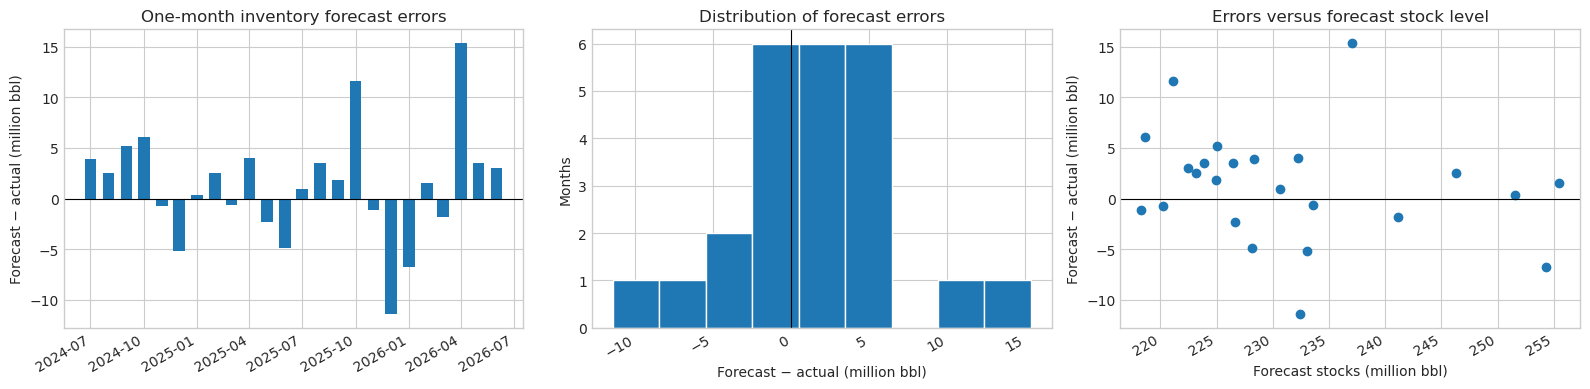

The selected one-month method has average signed error of **+1.30 million barrels**. Its largest absolute monthly miss is **15.36 million barrels**. Positive residuals mean stocks were overestimated. These plots show whether errors cluster in time or increase at particular inventory levels; they do not identify the economic cause of a miss.

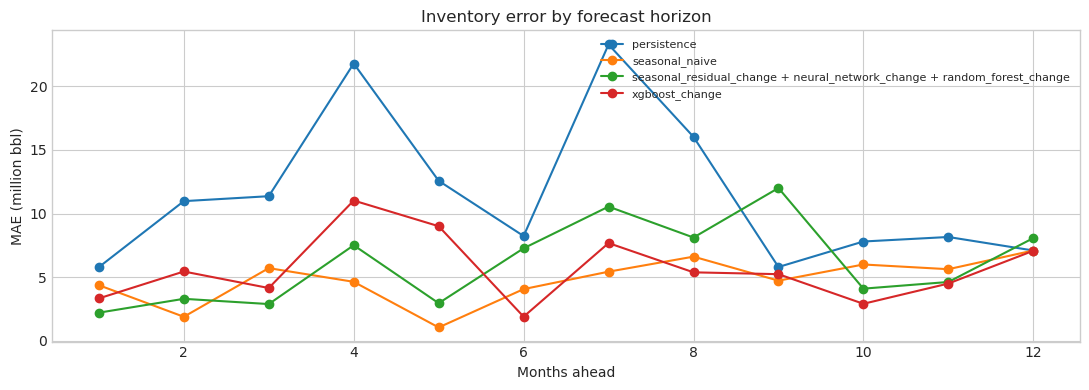

In [33]:
# Summarize national forecasts on matched months and origins.
one = tables['us_predictions'].query("split == 'holdout'").copy()
one_name = metadata.get('one_month_model', 'selected_padd_models')
long_name = metadata['year_ahead_model']
long = us_paths.copy()
history_stocks = tables['us_monthly_model'].set_index('month').stock_kb
base = long[long.model.eq(long_name)].copy()
assert not base.duplicated(['origin_month', 'month']).any()
year_ago = base.copy()
lag_dates = year_ago.month - pd.DateOffset(years=1)
assert (lag_dates <= year_ago.origin_month).all()
year_ago['predicted_kb'] = history_stocks.reindex(lag_dates).to_numpy()
assert year_ago.predicted_kb.notna().all()
year_ago['model'] = 'seasonal_naive'
long = pd.concat([long[~long.model.eq('seasonal_naive')], year_ago], ignore_index=True)

def summary_table(frame):
    rows = []
    reference = frame[frame.model.eq('persistence')].set_index(['origin_month', 'month'])
    for name, group in frame.groupby('model'):
        aligned = group.set_index(['origin_month', 'month']).sort_index()
        pd.testing.assert_index_equal(aligned.index, reference.sort_index().index)
        np.testing.assert_allclose(aligned.actual_kb, reference.sort_index().actual_kb)
        rows.append(dict(model=name, **score(group.actual_kb, group.predicted_kb),
                         bias_kb=(group.predicted_kb-group.actual_kb).mean()))
    result = pd.DataFrame(rows).set_index('model').sort_values('mae_kb')
    for benchmark, label in [('persistence','MAE improvement vs persistence (%)'),
                             ('seasonal_naive','MAE improvement vs year ago (%)')]:
        result[label] = 100*(1-result.mae_kb/result.loc[benchmark,'mae_kb'])
    return result

short_scores, long_scores = summary_table(one), summary_table(long)
for title, scores in [('One-month national results', short_scores), ('Twelve-month path results', long_scores)]:
    display(Markdown('### '+title))
    report = scores.copy()
    for column in ['mae_kb','rmse_kb','bias_kb']: report[column] /= 1000
    display(report.rename(columns={'mae_kb':'MAE (million bbl)', 'rmse_kb':'RMSE (million bbl)',
        'bias_kb':'Bias (million bbl)', 'r2':'R²', 'n':'Forecast observations'}))

best_short = short_scores.index[0]
display(Markdown(f"The lowest observed one-month MAE belongs to **`{best_short}`** "
    f"at **{short_scores.loc[best_short,'mae_kb']/1000:.2f} million barrels**. "
    f"The method selected before the final test is **`{one_name}`**. "
    "A winner identified after reviewing this test is a comparison result, not a new selection rule."))
for title, name, scores in [('Selected one-month method',one_name,short_scores),
                            ('Selected twelve-month method',long_name,long_scores)]:
    row = scores.loc[name]
    display(Markdown(f"**{title}: `{name}`.** MAE is **{row.mae_kb/1000:.2f} million barrels**, "
        f"RMSE is **{row.rmse_kb/1000:.2f} million barrels**, and R² is **{row.r2:.2f}**. "
        f"MAE improvement is **{100*(1-row.mae_kb/scores.loc['persistence','mae_kb']):.1f}%** versus persistence "
        f"and **{100*(1-row.mae_kb/scores.loc['seasonal_naive','mae_kb']):.1f}%** versus the same month last year. "
        "Positive percentages mean lower error; negative percentages mean higher error."))
development = tables['year_ahead_model_cv_metrics'].sort_values('mae_kb')
display(Markdown(f"`{long_name}` was selected using the lowest national MAE across six development-year paths. "
    f"The final path comparison has **{base.origin_month.nunique()} origins** and **{len(base)} forecast observations**. "
    "It tests only the displayed methods, so it cannot establish which of every candidate would perform best in the final period. "
    "Errors at different horizons share market history and are related. Negative R², where present, means squared errors exceed variation around the test-period mean."))

selected = one[one.model.eq(one_name)].sort_values('month').copy()
selected['error'] = (selected.predicted_kb-selected.actual_kb)/1000
fig, axes = plt.subplots(1,3,figsize=(16,4))
axes[0].bar(selected.month,selected.error,width=20)
axes[0].set(title='One-month inventory forecast errors',ylabel='Forecast − actual (million bbl)')
axes[1].hist(selected.error,bins=9,edgecolor='white')
axes[1].set(title='Distribution of forecast errors',xlabel='Forecast − actual (million bbl)',ylabel='Months')
axes[2].scatter(selected.predicted_kb/1000,selected.error)
axes[2].set(title='Errors versus forecast stock level',xlabel='Forecast stocks (million bbl)',ylabel='Forecast − actual (million bbl)')
for ax in [axes[0],axes[2]]: ax.axhline(0,color='black',linewidth=.8)
axes[1].axvline(0,color='black',linewidth=.8)
fig.autofmt_xdate(); plt.tight_layout(); plt.show()
display(Markdown(f"The selected one-month method has average signed error of **{selected.error.mean():+.2f} million barrels**. "
    f"Its largest absolute monthly miss is **{selected.error.abs().max():.2f} million barrels**. "
    "Positive residuals mean stocks were overestimated. These plots show whether errors cluster in time or increase at particular inventory levels; they do not identify the economic cause of a miss."))
fig, ax = plt.subplots(figsize=(11,4))
for name, group in long.groupby('model'):
    errors = group.assign(error=(group.predicted_kb-group.actual_kb).abs()/1000)
    errors.groupby('horizon').error.mean().plot(ax=ax,marker='o',label=name)
ax.set(title='Inventory error by forecast horizon',xlabel='Months ahead',ylabel='MAE (million bbl)')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()


### What this means for an S&D view

Start with the expected seasonal build or draw, then ask which supply or demand assumptions would move the balance away from that baseline. The statistical models summarize historical relationships; their forecasts do not provide a causal explanation for every barrel.

For gasoline, refinery and blender output adds supply, while domestic product supplied and exports remove barrels from the balance. More refinery runs do not translate one-for-one into gasoline production: product yields and blending matter. The model forecasts aggregate flows and does not explicitly simulate refinery yields or blend recipes. Finished gasoline and blendstocks must be counted consistently to avoid double-counting internal conversion.

National inventory errors can be smaller than regional errors because PADD misses offset. Read the regional diagnostics alongside the national score. The twelve-month outlook is conditional on the modeled flows and does not include calibrated uncertainty ranges. A stock forecast alone does not establish a price direction or trading return.

The historical accounting residual and the forecast residual answer different questions. The first is the difference between reported net flows and observed stock change; the second is forecast stocks minus actual stocks. Neither should be silently treated as new physical supply.

Run All repeats the full experiment. The report-refresh command in the README rebuilds charts and tables from saved results. Model settings are selected on development data, but the final period has already been reviewed, so the reported accuracy remains a retrospective check.

In this saved run, the selected twelve-month XGBoost model has 18.2% higher MAE than the same-month-last-year benchmark, although it beats persistence. The year-ago baseline therefore provides the stronger of these two comparisons for gasoline. The model would need to improve on that seasonal reference across more forecast years before claiming consistent year-ahead value.

### Reproducibility checks included in the notebook

Check saved inputs, finished versus total gasoline stocks, forecast timing, national aggregation, and separation of development targets from the final evaluation period. These checks run on the same inputs and outputs just used for the analysis.

In [34]:
# Check the model's stock scope and accounting identities, then perturb the
# last target observation to verify target-month isolation. Finally require
# the national forecast to equal the sum of the five regional forecasts.

np.testing.assert_allclose(panel.stock_kb, panel.finished_stock_kb + panel.blending_stock_kb, atol=1, rtol=0)
np.testing.assert_allclose(panel.production_kb, panel.finished_production_kb-panel.blending_net_inputs_kb)
check_history=panel[panel.padd.eq(1)].iloc[:40].copy()
before=supervised(check_history)
# Perturb the final target month's stocks and flows substantially to test that
# its own inputs cannot see target-month information.
check_history.loc[check_history.index[-1],FLOWS+['stock_kb']]+=100000
changed=supervised(check_history)
# Only target labels may change after perturbing the final observation. All
# predictors, origin dates, and flow-identity forecasts must remain identical.
feature_columns=[c for c in before if c not in ['actual_kb','delta_kb']]
pd.testing.assert_frame_equal(before[feature_columns],changed[feature_columns])
np.testing.assert_allclose(tables['us_forecast_12m'].stock_kb,
    tables['padd_forecast_12m'].groupby('month').stock_kb.sum())
print('Source integrity, stock scope, target-month isolation, and aggregation checks passed.')

Source integrity, stock scope, target-month isolation, and aggregation checks passed.


In [35]:
# Inspect run configuration and saved artifacts, and validate output shape: no
# duplicate forecasts, all five PADDs each month, and a full 12-month outlook.

display(pd.Series(metadata, name='Configuration'))
print('Saved result files:')
for path in sorted(OUTPUT.iterdir()):
    print(path.name)
assert not tables['padd_predictions'].duplicated(['padd','month','model','split']).any()
assert tables['padd_forecast_12m'].groupby('month').padd.nunique().eq(5).all()
assert len(outlook) == 12
print('Notebook checks passed.')

product                  Total motor gasoline: finished motor gasoline ...
covid_exclusion          {'start': '2020-03-01', 'end': '2021-03-01', '...
stock_units                                  thousand barrels at month end
flow_units                             thousand barrels per calendar month
equation                 S[t] = S[t-1] + (finished refinery/blender net...
data_start                                                      2007-01-01
data_end                                                        2026-06-01
cv                       10 expanding folds, 12 eligible test months ea...
holdout_start                                                   2024-07-01
forecast_timing          One month after latest observed EIA month; con...
one_month_models         {'1': 'seasonal_residual_change', '2': 'neural...
one_month_model_label    seasonal_residual_change + neural_network_chan...
year_ahead_model                                            xgboost_change
horizon_selection        

Saved result files:
all_fitted_models.joblib
best_parameters.csv
candidate_addition_comparison.csv
candidate_models.json
constrained_model_coefficients.csv
fit_warnings.csv
fitted_horizon_models.joblib
fitted_models.joblib
fold_metrics.csv
grid_search_results.csv
historical_balance_exceptions.csv
latest_forecast.csv
model_metadata.json
padd_forecast_12m.csv
padd_model_metrics.csv
padd_monthly_model.csv
padd_predictions.csv
recursive_benchmark_predictions.csv
recursive_cv_predictions.csv
recursive_holdout_metrics.csv
recursive_holdout_predictions.csv
refit_comparison.csv
regional_error_review.csv
selected_models.csv
training_sample_audit.csv
us_forecast_12m.csv
us_model_metrics.csv
us_monthly_model.csv
us_predictions.csv
us_recursive_cv_predictions.csv
us_recursive_holdout_predictions.csv
us_recursive_horizon_metrics.csv
year_ahead_model_cv_metrics.csv
year_ahead_refit_comparison.csv
Notebook checks passed.
